# 🏢 Şirket Analizi Notebook'u

## Amaç

Bu notebook, **Borsa İstanbul (BIST)** hisselerinden herhangi biri için derinlemesine finansal analiz yapmak amacıyla geliştirilmiştir. Tek bir şirketin çeyreklik/yıllık finansal verileri işlenerek; büyüme, karlılık, likidite, bilanço sağlığı, değerleme ve istatistiksel tahmin analizleri sunulmaktadır.

---

## Neler Analiz Edilir?

| Kategori | İçerik |
|---|---|
| **Büyüme** | Çeyreklik (QoQ) ve yıllık (YoY) gelir, kâr ve varlık büyüme oranları |
| **Karlılık** | Brüt kâr, FAVÖK, net kâr marjları; ROE, ROA, ROIC |
| **Bilanço** | Aktif-pasif yapısı, toplam borçlar, özkaynaklar, net işletme sermayesi |
| **Likidite** | Cari oran, asit-test oranı, net borç / FAVÖK |
| **Verimlilik** | Alacak tahsil süresi, stok devir hızı, aktif devir hızı |
| **Nakit Akışı** | İşletme, yatırım ve finansman nakit akımları; serbest nakit akımı |
| **Değerleme** | F/K, FD/FAVÖK, PD/DD çarpanları; istatistiksel model ile gelecek dönem tahmini |
| **Skor Kartı** | Her kategori için hesaplanan bileşik skor ve genel finansal sinyal |

---

## Nasıl Çalışır?

1. Hisse kodu girilir (örn. `THYAO`, `ASTOR`, `CIMSA`).
2. İstatistiksel değerleme yapılıp yapılmayacağı seçilir (`EVET` / `HAYIR`).
3. Eğer değerleme `EVET` seçildiyse, hazır TÜFE tahmini kullanılıp kullanılmayacağı sorulur.
4. Finansal veriler `balancesheet` ve `yfinance` ile çekilir; oranlar hesaplanır; tablolar ve görseller üretilir.

---

## EVDS API Anahtarı

EVDS (Elektronik Veri Dağıtım Sistemi), Türkiye Cumhuriyet Merkez Bankası'nın (TCMB) makroekonomik veri platformudur. **TÜFE (Tüketici Fiyat Endeksi)** verisi bu platform üzerinden çekilmektedir.

### API Anahtarı Ne Zaman Gereklidir?

| İstatistiksel Değerleme | Hazır TÜFE Tahmini | API Anahtarı |
|---|---|---|
| HAYIR | — | ❌ Gerekmez |
| EVET | EVET | ❌ Gerekmez |
| EVET | **HAYIR** | ✅ **Zorunlu** |

> TÜFE kendi istatistiksel modelinizle tahmin edilecekse EVDS üzerinden geçmiş veri çekilmesi gerektiğinden API anahtarı zorunludur.

### API Anahtarı Nasıl Alınır?

1. [https://evds2.tcmb.gov.tr](https://evds2.tcmb.gov.tr) adresine gidin.
2. Sağ üst köşeden **Üye Ol** / **Login** bağlantısına tıklayın.
3. Kayıt olduktan ve giriş yaptıktan sonra profil sayfanıza gidin.
4. **"API Anahtarı"** bölümünden anahtarınızı oluşturun ve kopyalayın.

### API Anahtarı Kodda Nerede Kullanılır?

Bu notebook içinde API anahtarı aşağıdaki iki fonksiyona parametre olarak iletilmektedir:

```python
# Fonksiyon tanımları — api_key parametresi olarak alınır:
def TUFE_alma(df, api_key):
    evds = evdsAPI(api_key)          # ← API anahtarı burada kullanılır
    ...

def TUFE_alma_2(df, api_key):
    evds = evdsAPI(api_key)          # ← API anahtarı burada kullanılır
    ...
```

Notebook'u doğrudan çalıştırırken API anahtarınızı aşağıdaki gibi tanımlayabilirsiniz:

```python
api_key = "BURAYA_KENDI_API_ANAHTARINIZI_YAZIN"
makro_data = TUFE_alma(df, api_key)
```

> **Web Uygulaması Kullanımı:** Web arayüzü üzerinden analiz çalıştırıyorsanız, "EVDS API Key" alanına anahtarınızı girmeniz yeterlidir; kod otomatik olarak ilgili fonksiyonlara iletir.

---

## Bağımlılıklar

```
pandas · numpy · matplotlib · seaborn · yfinance · balancesheet
evds · statsmodels · scikit-learn · requests · beautifulsoup4
```

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import math
from balancesheet import bilanco_cekme
from evds import evdsAPI
import itertools
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.tsa.api as smt
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', None)

İşlem başladı


Hisse kodu giriniz (örn: THYAO):  ASTOR
İstatiksel modeller ile değerleme yapmak istiyorsanız EVET, istemiyorsanız HAYIR yazınız:  EVET


ASTOR bilançosu indirildi.

ŞELALE GRAFİKLERİ İLE DÖNEMSEL DEĞİŞİMLER




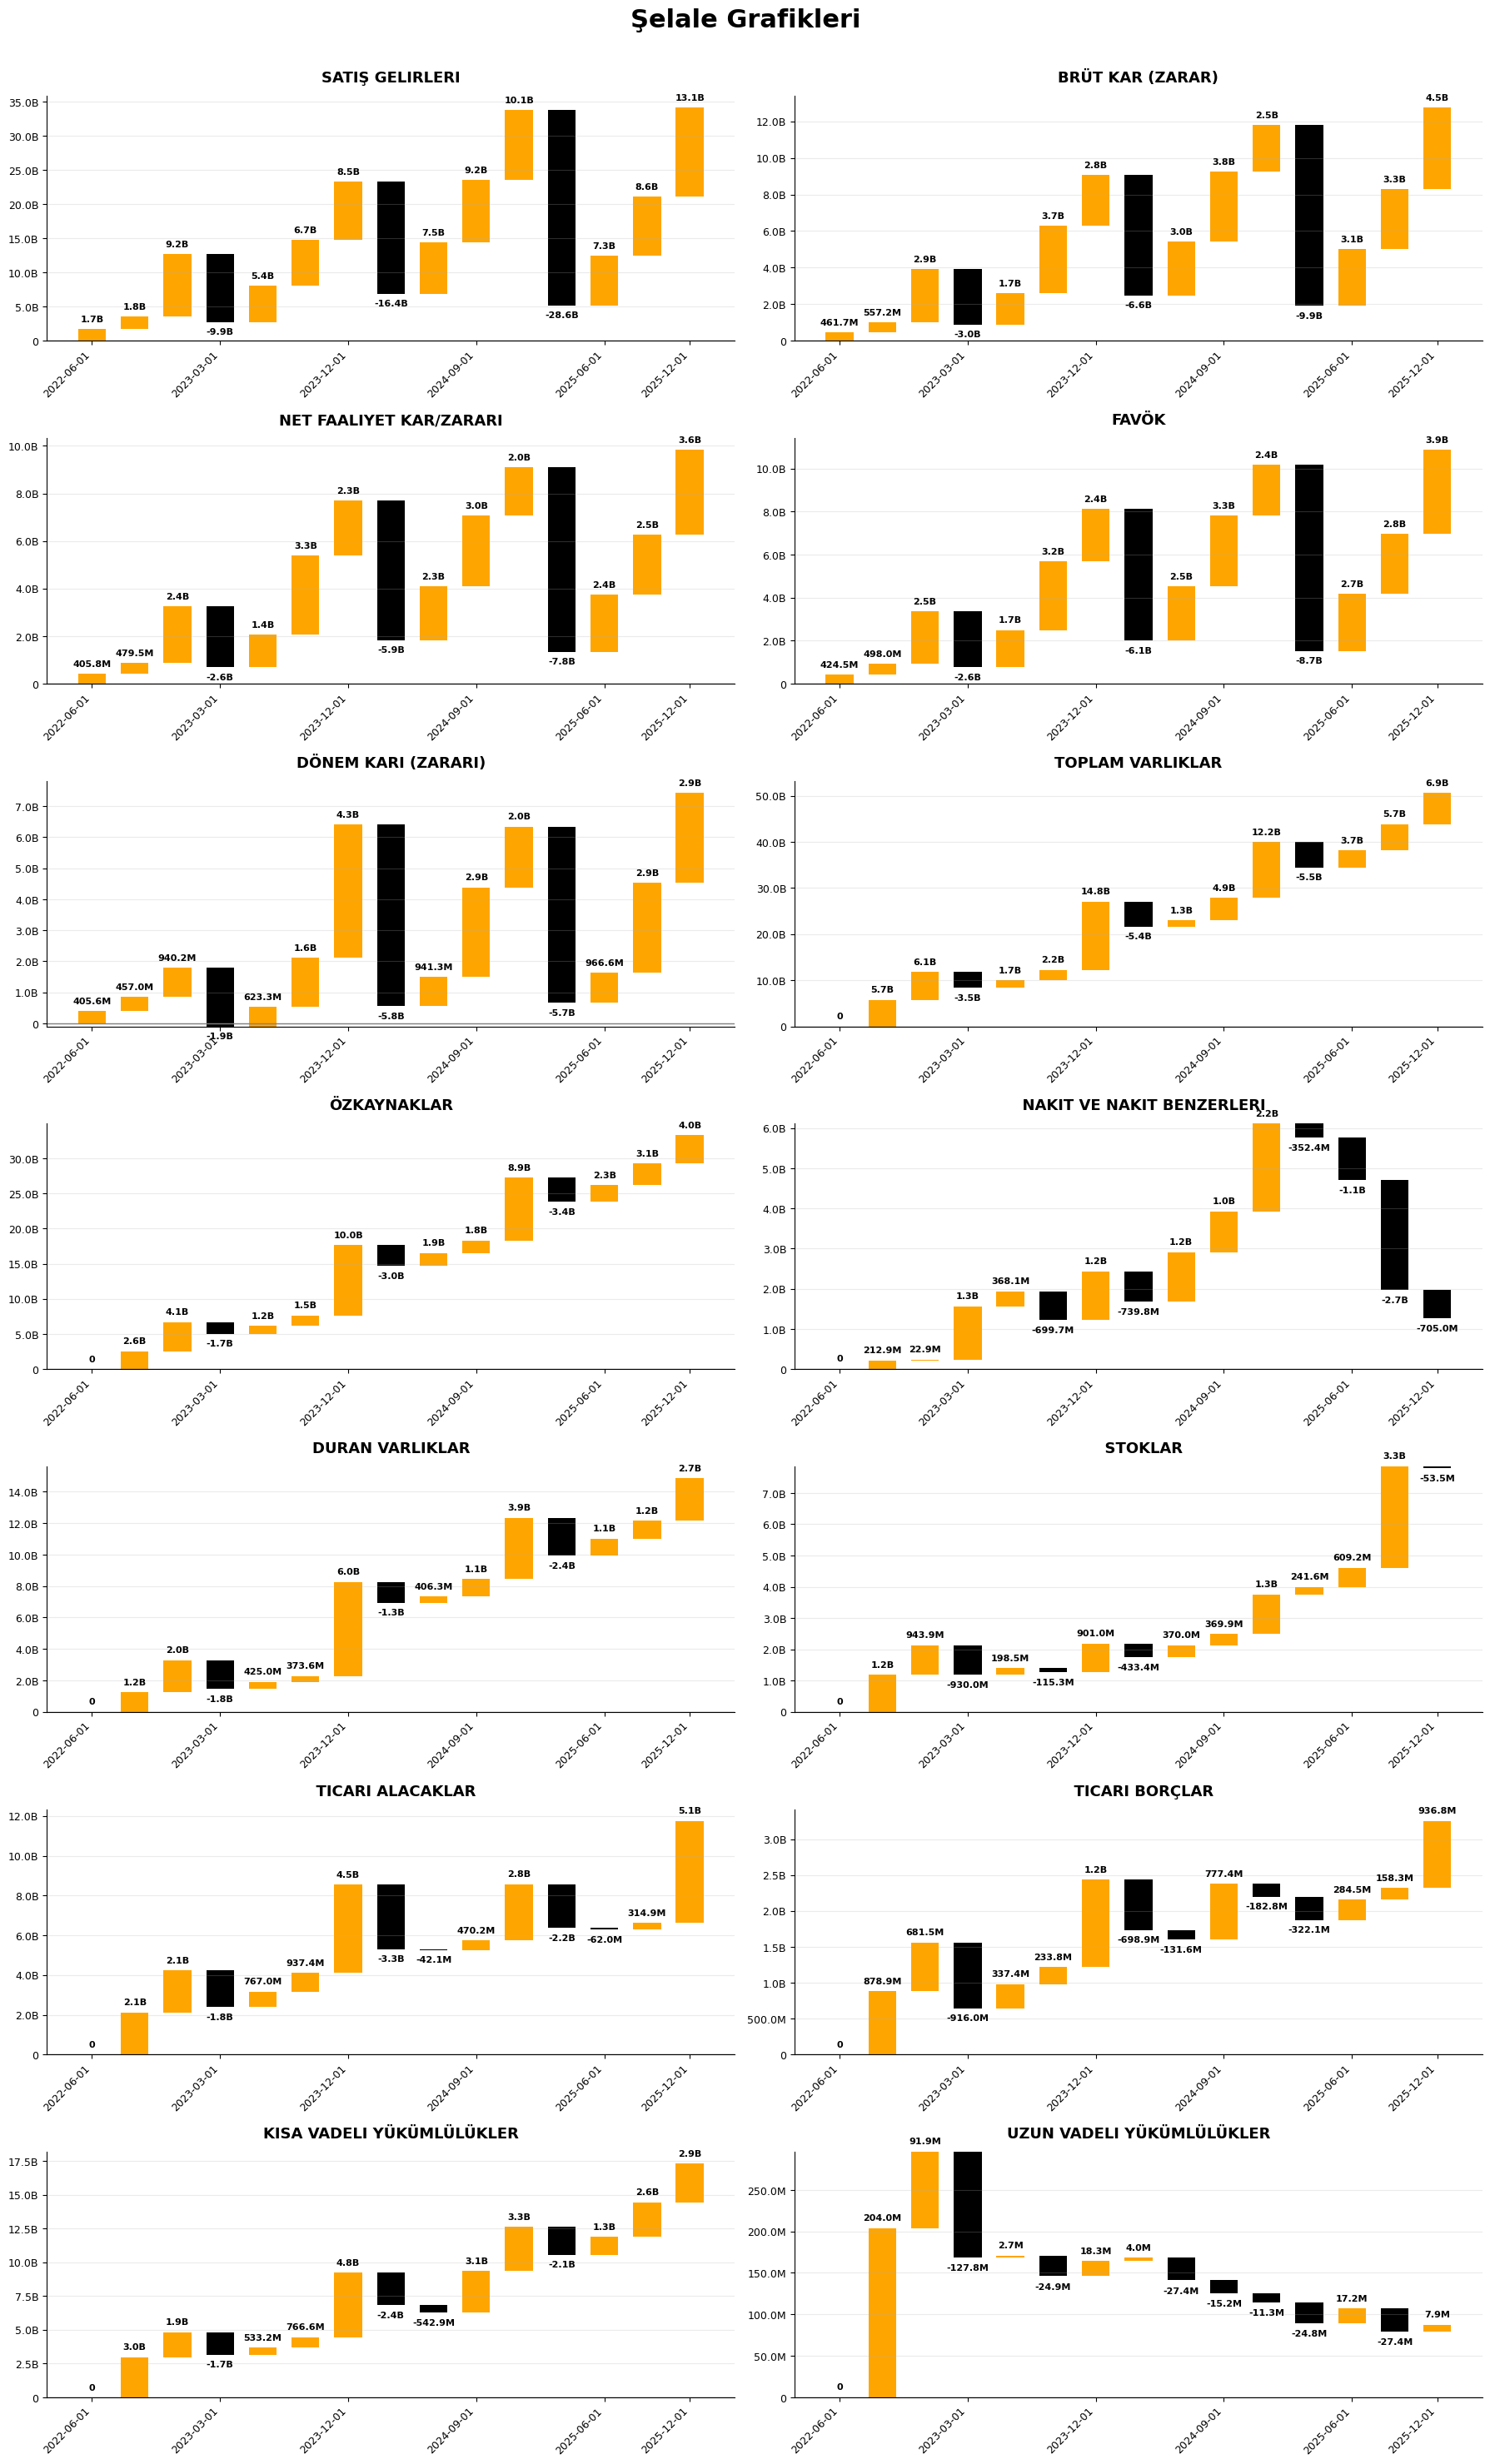

****************************************

Bilanço       Satış Gelirleri  BRÜT KAR (ZARAR)  Net Faaliyet Kar/Zararı  \
2022-06-01   1,708,322,859.00    461,670,680.00           405,810,919.00   
2022-09-01   1,836,917,008.00    557,208,555.00           479,501,918.00   
2022-12-01   9,157,356,125.00  2,895,535,779.00         2,383,225,643.00   
2023-03-01  -9,943,126,530.00 -3,022,294,342.00        -2,578,618,168.00   
2023-06-01   5,374,119,985.00  1,698,728,851.00         1,372,011,447.00   
2023-09-01   6,673,232,687.00  3,696,533,519.00         3,316,494,657.00   
2023-12-01   8,533,052,005.00  2,793,704,383.00         2,320,887,745.00   
2024-03-01 -16,406,138,273.00 -6,590,373,019.00        -5,879,806,630.00   
2024-06-01   7,452,671,940.00  2,950,162,454.00         2,258,881,606.00   
2024-09-01   9,242,061,387.00  3,795,757,282.00         3,002,991,829.00   
2024-12-01  10,139,483,774.00  2,544,470,511.00         2,006,058,542.00   
2025-03-01 -28,571,162,654.00 -9,867,036,281.0

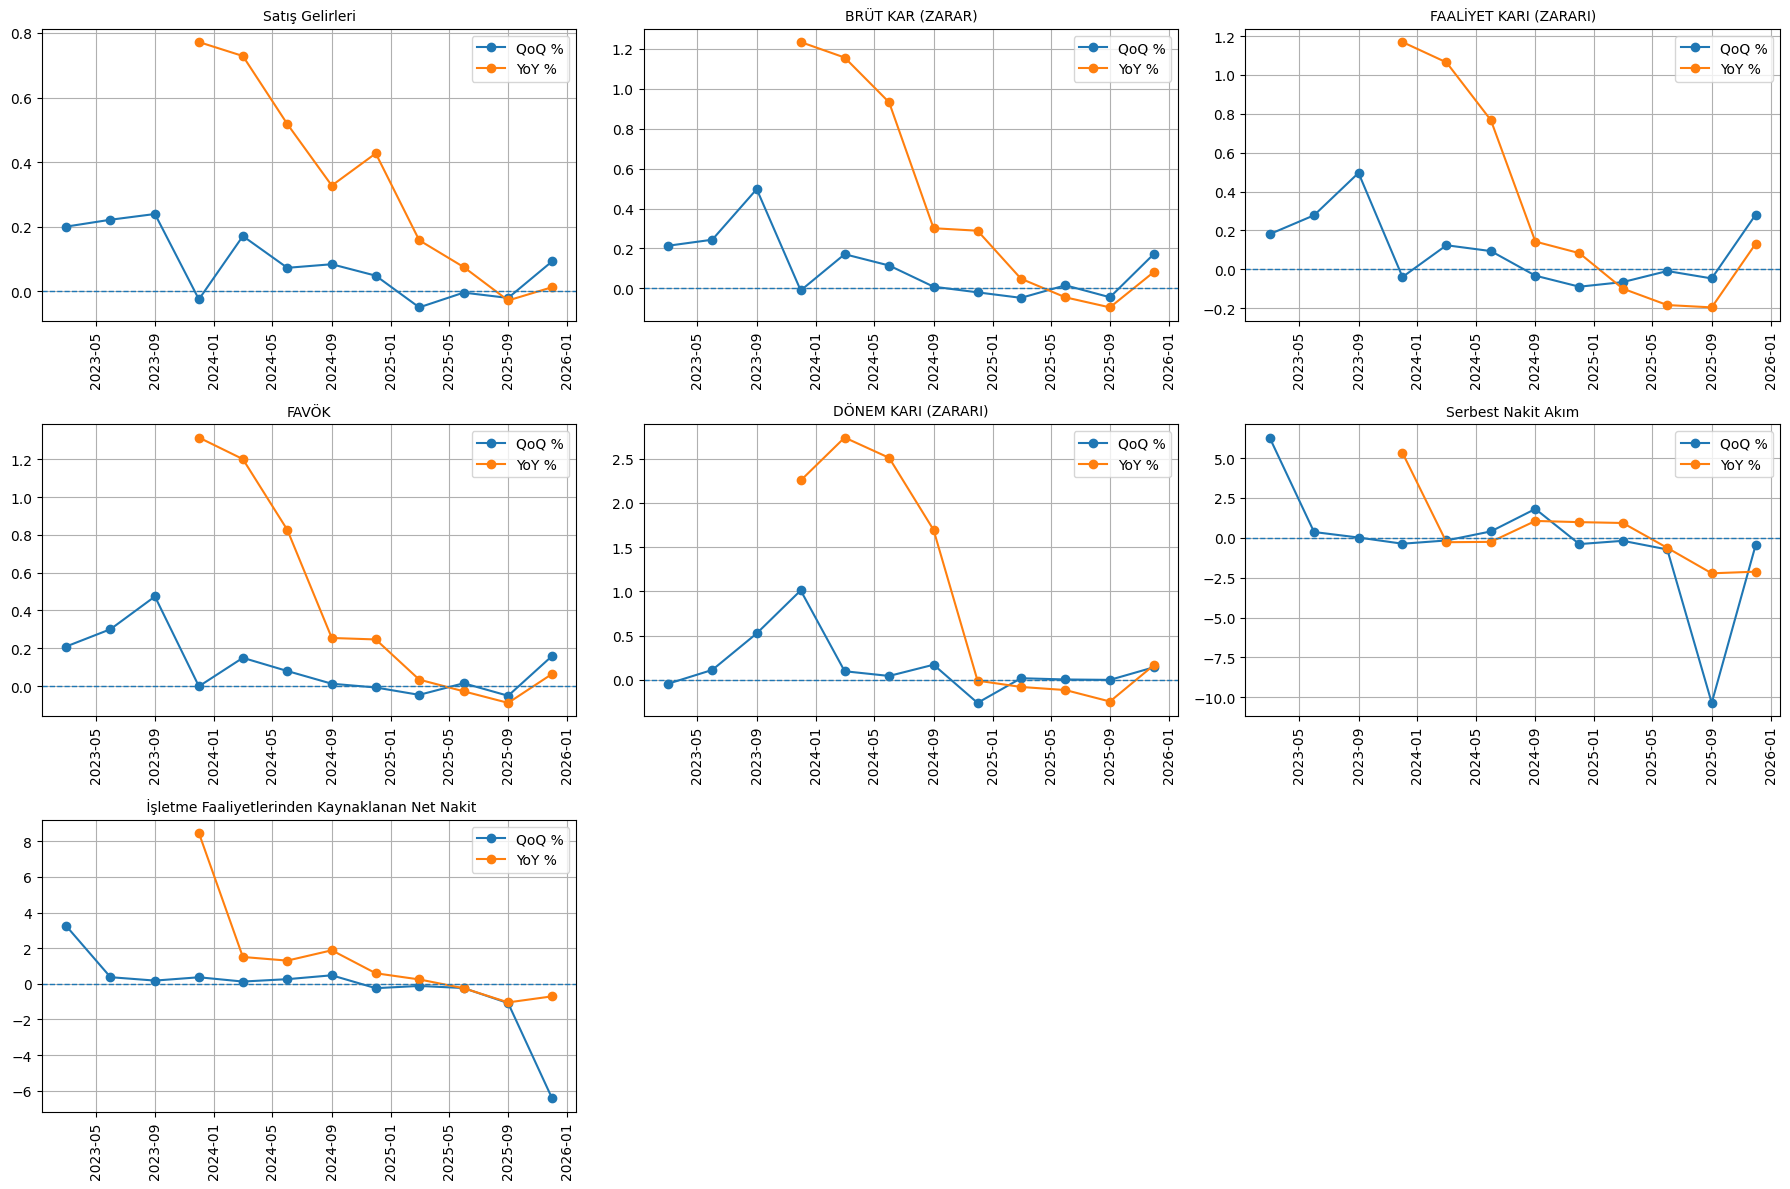

****************************************

            Satış Gelirleri_qoq_%  Satış Gelirleri_yoy_%  \
2022-12-01                    NaN                    NaN   
2023-03-01                   0.20                    NaN   
2023-06-01                   0.22                    NaN   
2023-09-01                   0.24                    NaN   
2023-12-01                  -0.02                   0.77   
2024-03-01                   0.17                   0.73   
2024-06-01                   0.07                   0.52   
2024-09-01                   0.08                   0.33   
2024-12-01                   0.05                   0.43   
2025-03-01                  -0.05                   0.16   
2025-06-01                  -0.00                   0.08   
2025-09-01                  -0.02                  -0.03   
2025-12-01                   0.09                   0.01   

            BRÜT KAR (ZARAR)_qoq_%  BRÜT KAR (ZARAR)_yoy_%  \
2022-12-01                     NaN                     

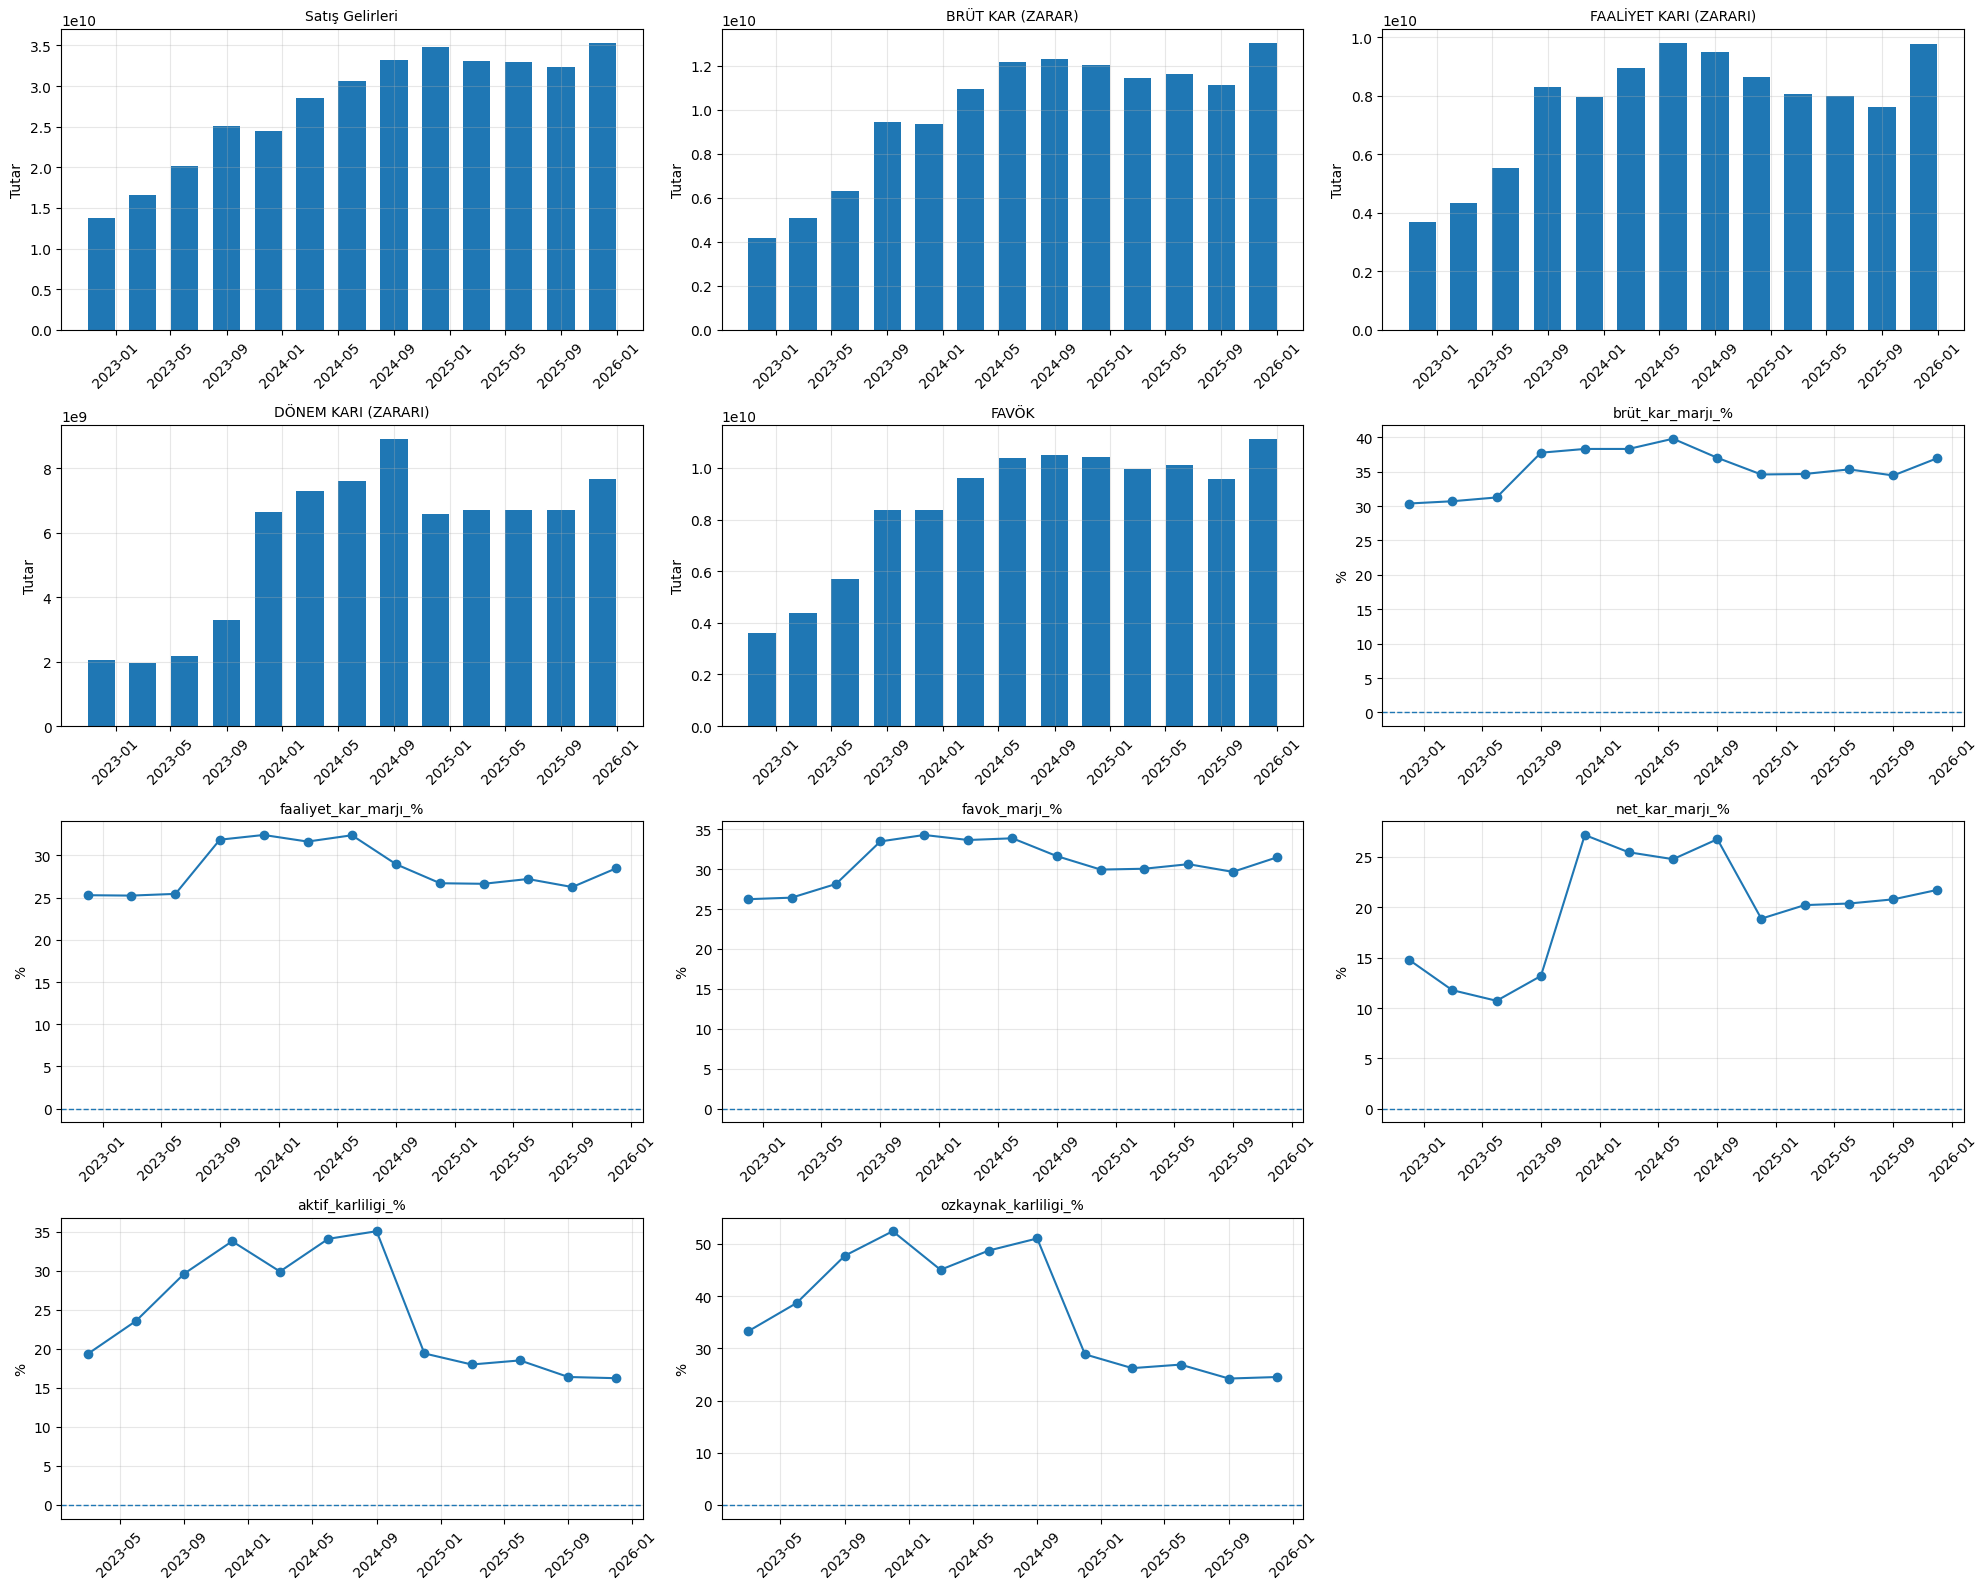

****************************************

             Satış Gelirleri  BRÜT KAR (ZARAR)  FAALİYET KARI (ZARARI)  \
2022-12-01 13,783,507,804.00  4,185,251,821.00        3,674,888,130.00   
2023-03-01 16,542,977,266.00  5,077,372,493.00        4,339,844,406.00   
2023-06-01 20,208,774,392.00  6,314,430,664.00        5,547,099,600.00   
2023-09-01 25,045,090,071.00  9,453,755,628.00        8,299,344,208.00   
2023-12-01 24,420,785,951.00  9,351,924,232.00        7,972,594,884.00   
2024-03-01 28,595,052,355.00 10,950,517,966.00        8,961,273,145.00   
2024-06-01 30,673,604,310.00 12,201,951,569.00        9,803,195,562.00   
2024-09-01 33,242,433,010.00 12,301,175,332.00        9,484,700,713.00   
2024-12-01 34,848,864,779.00 12,051,941,460.00        8,637,960,937.00   
2025-03-01 33,111,919,226.00 11,475,295,426.00        8,072,133,145.00   
2025-06-01 32,976,814,382.00 11,648,086,068.00        8,002,511,797.00   
2025-09-01 32,298,426,889.00 11,124,476,769.00        7,628,721,050.00

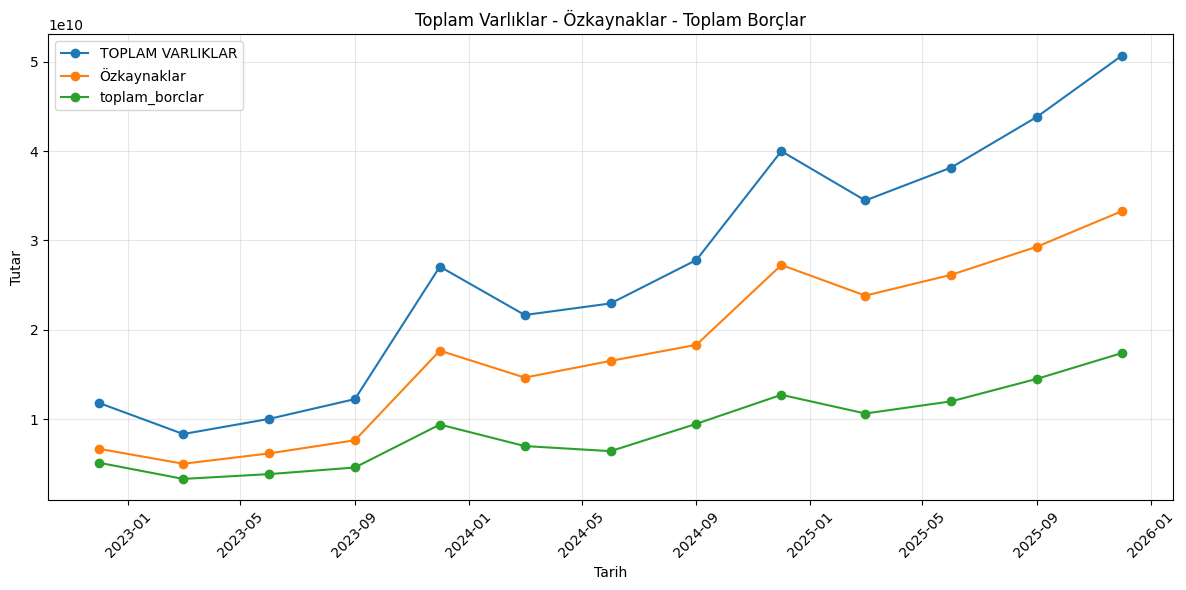

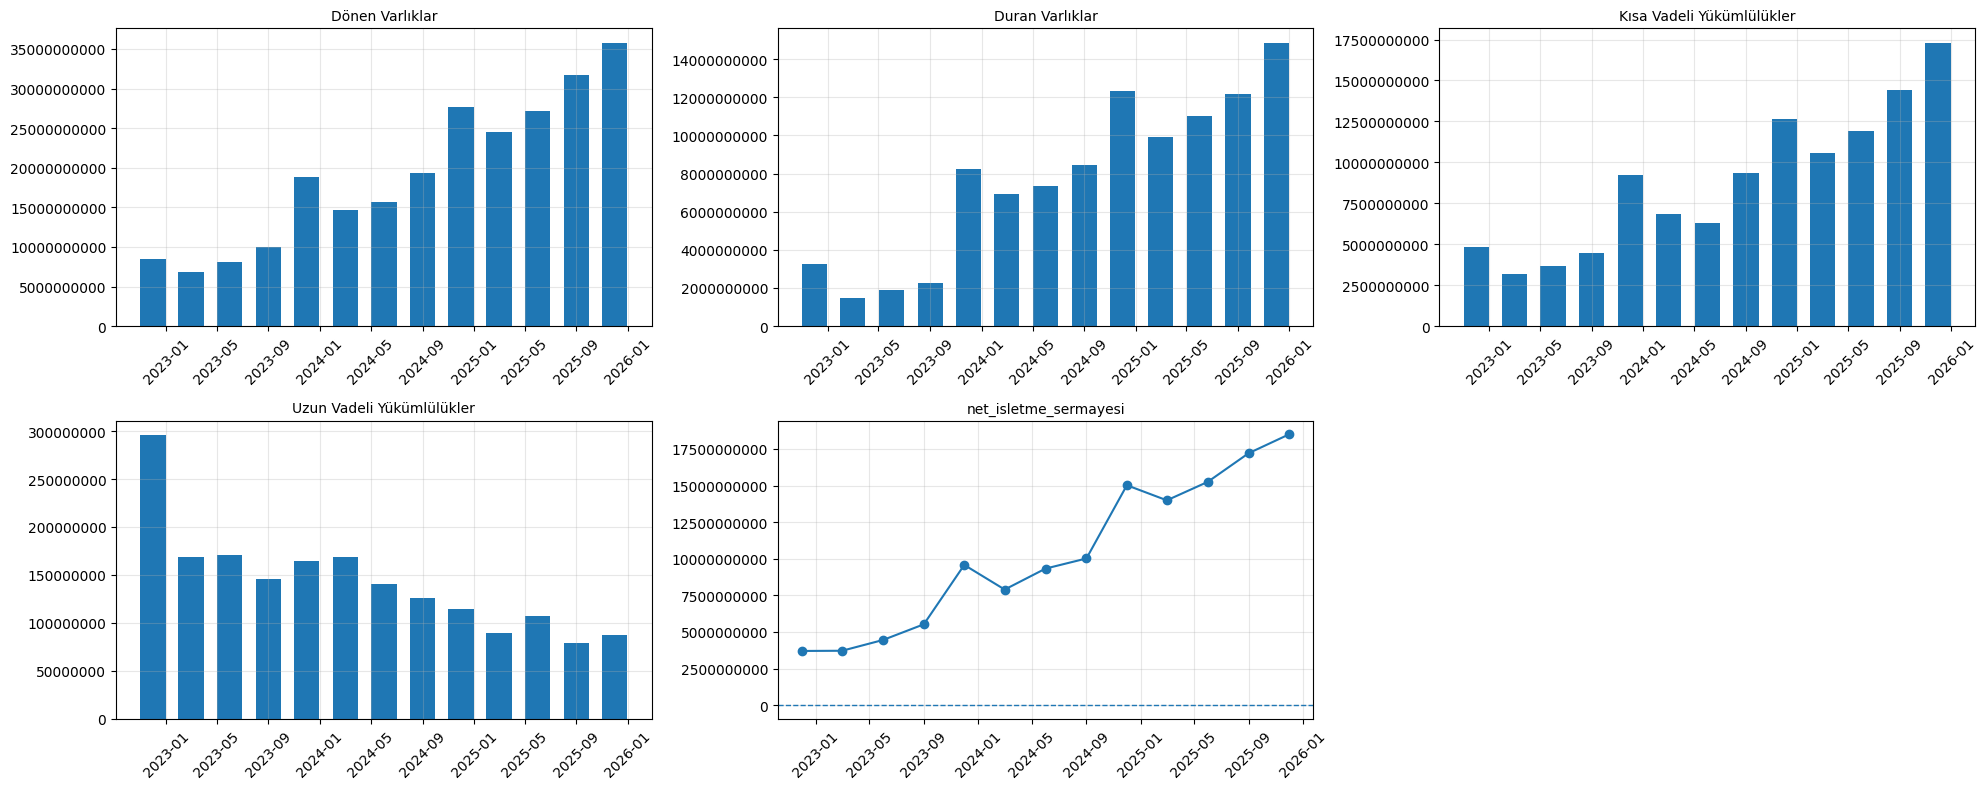

****************************************

             Dönen Varlıklar   Duran Varlıklar  TOPLAM VARLIKLAR  \
2022-12-01  8,528,322,665.00  3,282,242,068.00 11,810,564,733.00   
2023-03-01  6,869,505,689.00  1,475,892,204.00  8,345,397,893.00   
2023-06-01  8,137,413,644.00  1,900,921,315.00 10,038,334,959.00   
2023-09-01  9,977,538,488.00  2,274,555,100.00 12,252,093,588.00   
2023-12-01 18,818,855,765.00  8,257,720,575.00 27,076,576,340.00   
2024-03-01 14,726,371,705.00  6,934,956,526.00 21,661,328,231.00   
2024-06-01 15,616,070,284.00  7,341,207,860.00 22,957,278,144.00   
2024-09-01 19,384,400,220.00  8,436,597,599.00 27,820,997,819.00   
2024-12-01 27,639,968,384.00 12,350,158,714.00 39,990,127,098.00   
2025-03-01 24,543,880,659.00  9,929,560,043.00 34,473,440,702.00   
2025-06-01 27,143,693,526.00 11,013,623,917.00 38,157,317,443.00   
2025-09-01 31,652,477,953.00 12,176,128,760.00 43,828,606,713.00   
2025-12-01 35,814,744,751.00 14,869,686,895.00 50,684,431,646.00   

     

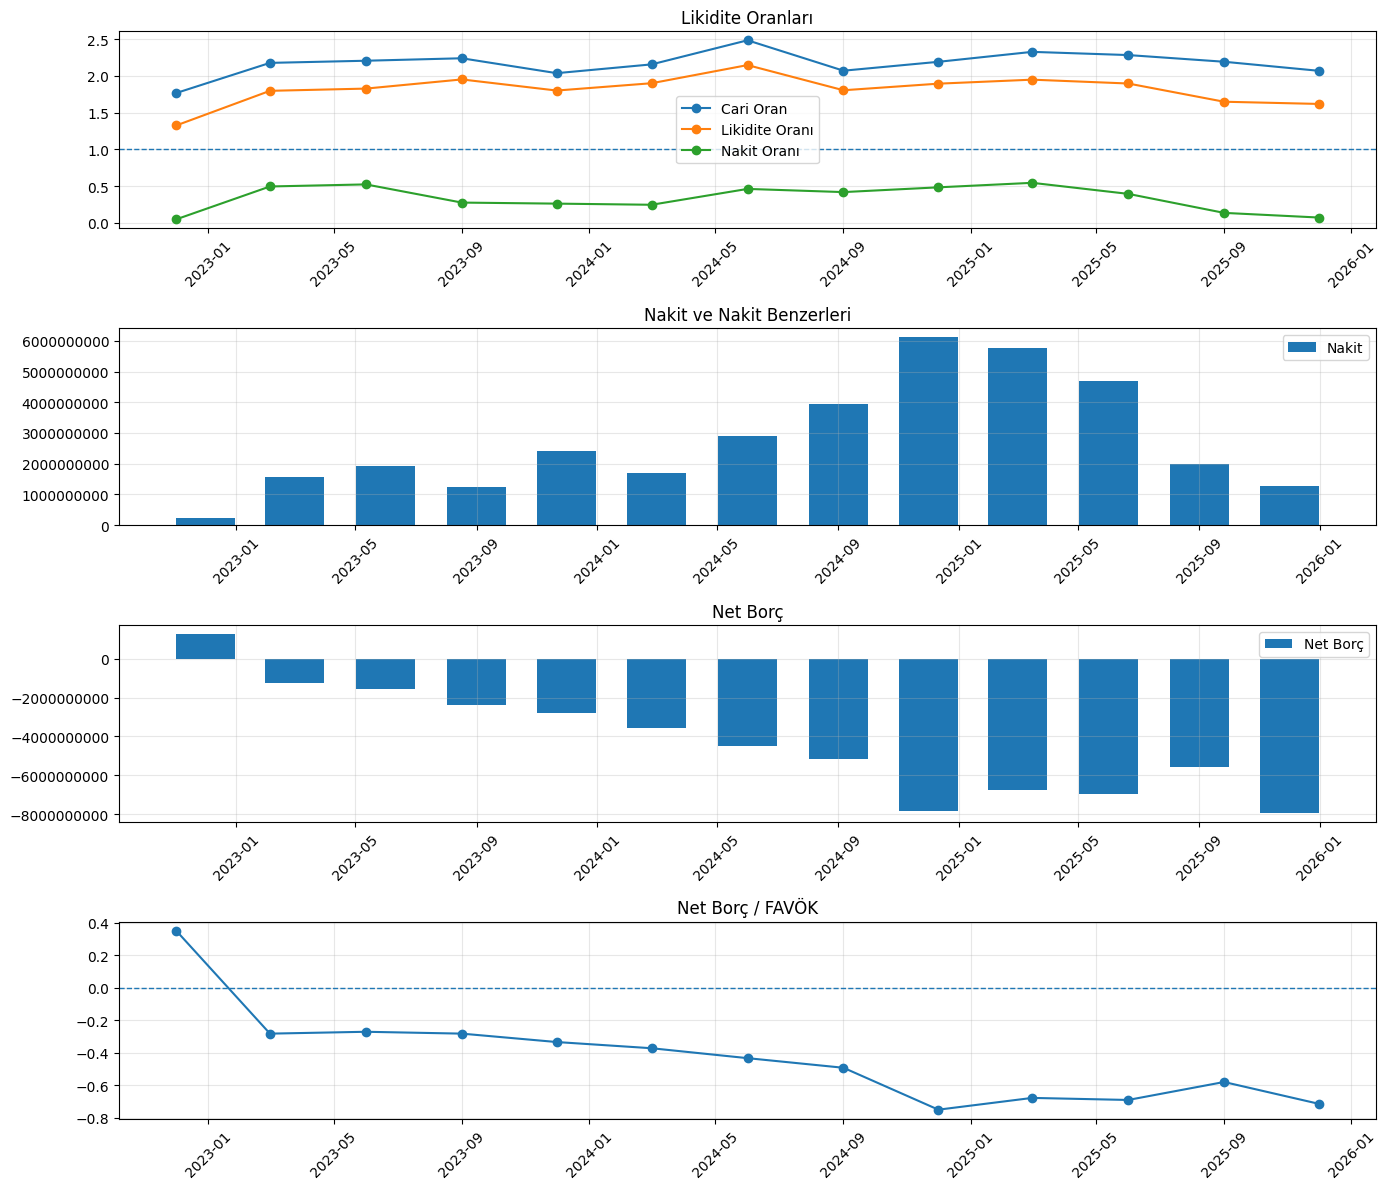


NAKİT DÖNGÜSÜ


 FAALİYET VERİMLİLİĞİ / YETERLİLİK ANALİZİ (SON DÖNEM)

aktif_devir_hizi: 0.79 → 0.75 | Azalış: 0.04 (%5.22)
alacak_devir_hizi: 5.00 → 3.84 | Azalış: 1.16 (%23.19)
stok_devir_hizi: 3.40 → 2.84 | Azalış: 0.56 (%16.40)
borc_devir_hizi: 9.46 → 7.99 | Azalış: 1.47 (%15.56)
alacak_tahsil_suresi_gun: 72.97 → 95.01 | Artış: 22.04 (%30.20)
stok_gun_sayisi: 107.29 → 128.33 | Artış: 21.04 (%19.61)
borc_odeme_suresi: 38.59 → 45.71 | Artış: 7.11 (%18.43)
nakit_dongu: 141.67 → 177.64 | Artış: 35.97 (%25.39)


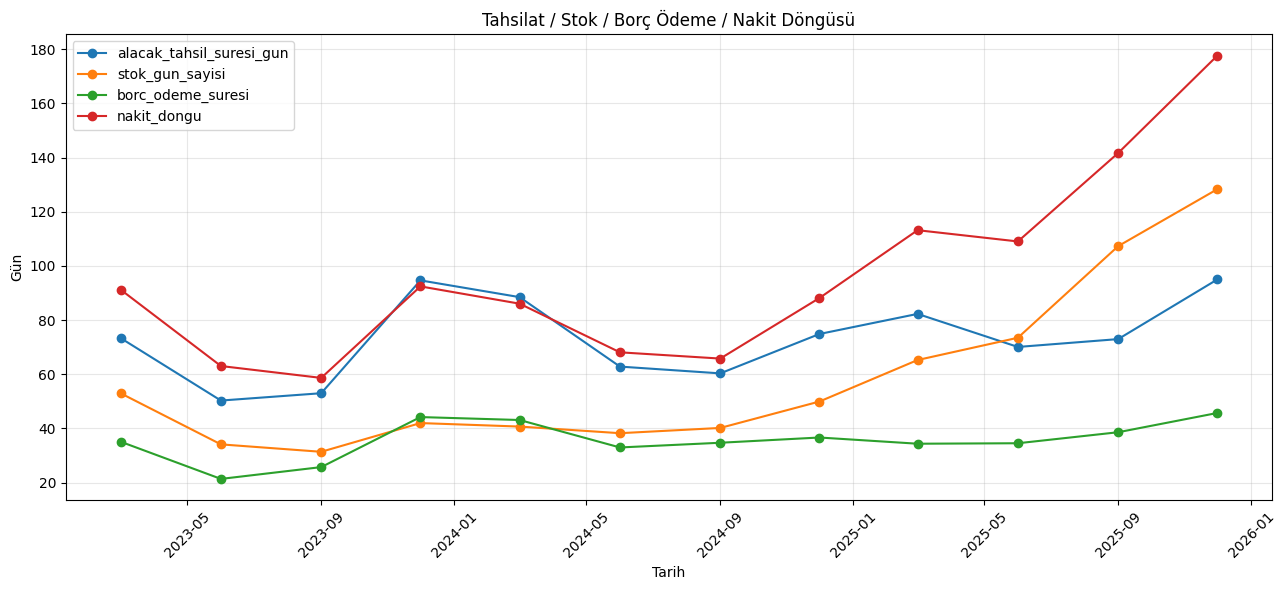

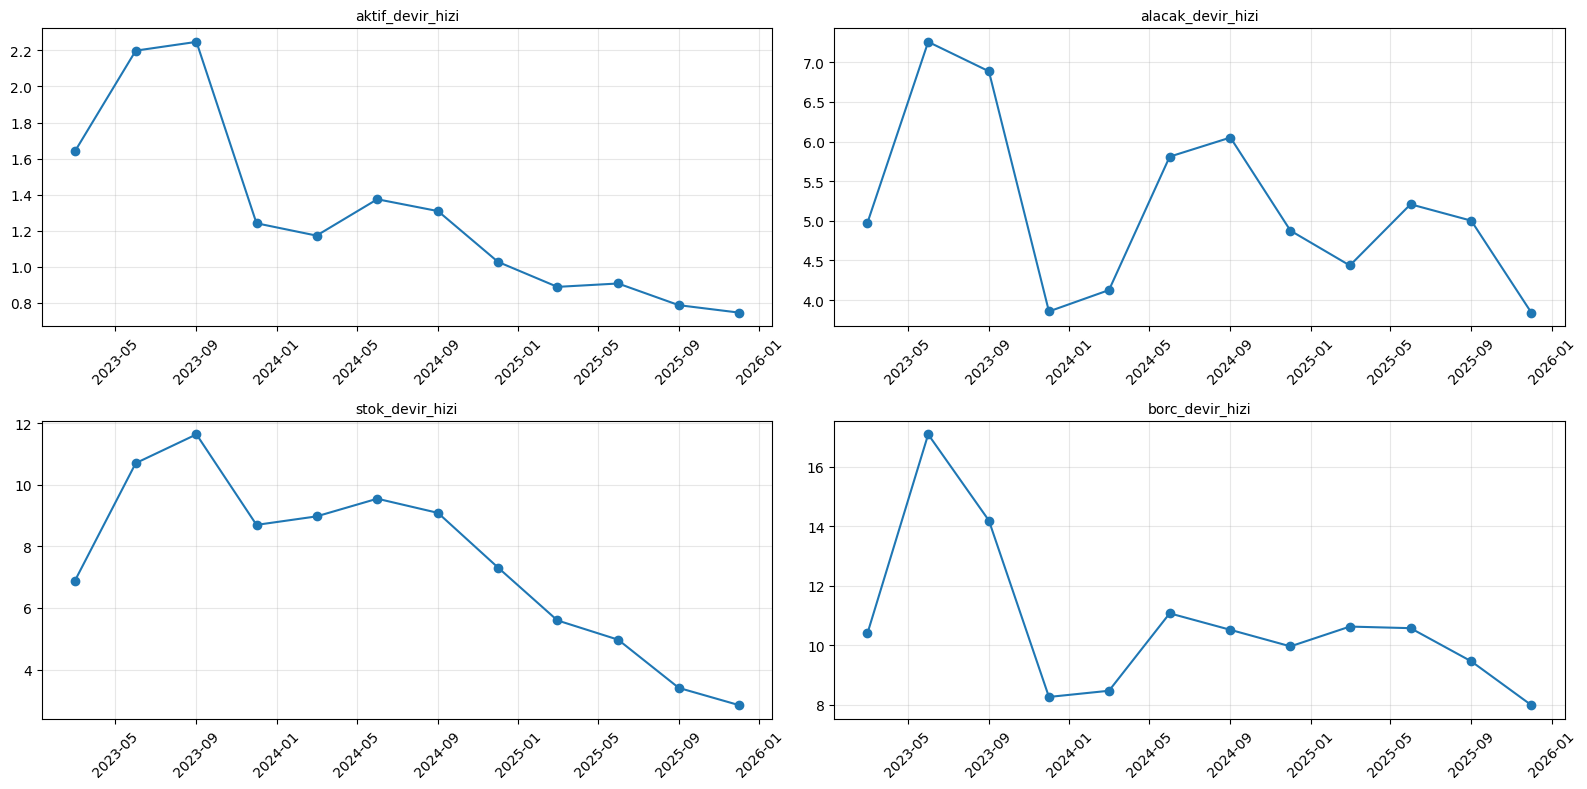

****************************************

            aktif_devir_hizi  alacak_devir_hizi  stok_devir_hizi  \
2022-12-01               NaN                NaN              NaN   
2023-03-01              1.64               4.98             6.89   
2023-06-01              2.20               7.26            10.70   
2023-09-01              2.25               6.89            11.64   
2023-12-01              1.24               3.86             8.70   
2024-03-01              1.17               4.13             8.97   
2024-06-01              1.37               5.81             9.55   
2024-09-01              1.31               6.05             9.09   
2024-12-01              1.03               4.88             7.31   
2025-03-01              0.89               4.44             5.59   
2025-06-01              0.91               5.21             4.97   
2025-09-01              0.79               5.00             3.40   
2025-12-01              0.75               3.84             2.84   

     

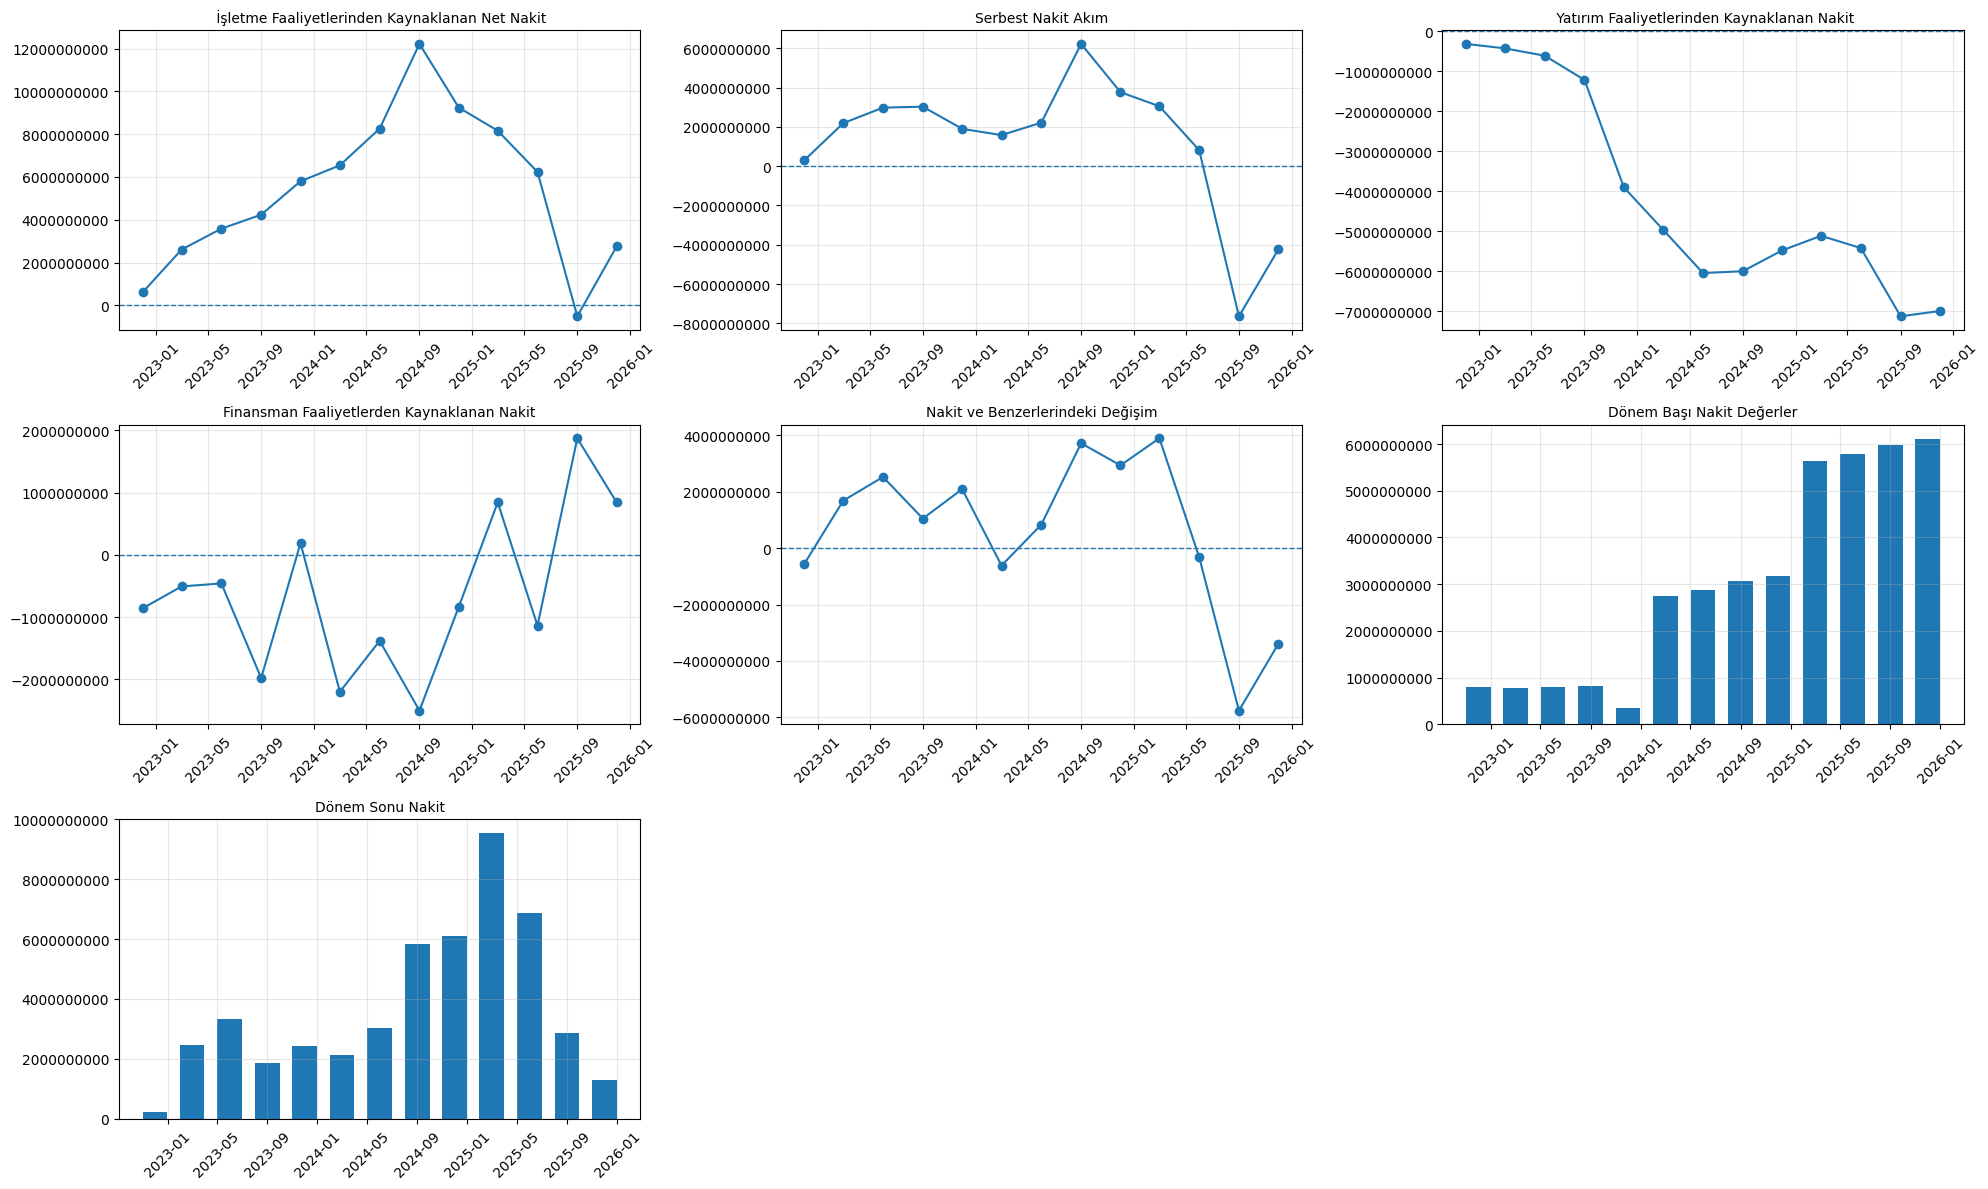

****************************************

             İşletme Faaliyetlerinden Kaynaklanan Net Nakit  \
2022-12-01                                   613,050,514.00   
2023-03-01                                 2,610,902,503.00   
2023-06-01                                 3,585,545,436.00   
2023-09-01                                 4,238,440,699.00   
2023-12-01                                 5,799,052,647.00   
2024-03-01                                 6,544,895,933.00   
2024-06-01                                 8,258,632,791.00   
2024-09-01                                12,216,607,099.00   
2024-12-01                                 9,242,157,398.00   
2025-03-01                                 8,160,708,156.00   
2025-06-01                                 6,235,931,774.00   
2025-09-01                                  -508,064,172.00   
2025-12-01                                 2,756,906,505.00   

            Serbest Nakit Akım   Yatırım Faaliyetlerinden Kaynaklanan Nakit

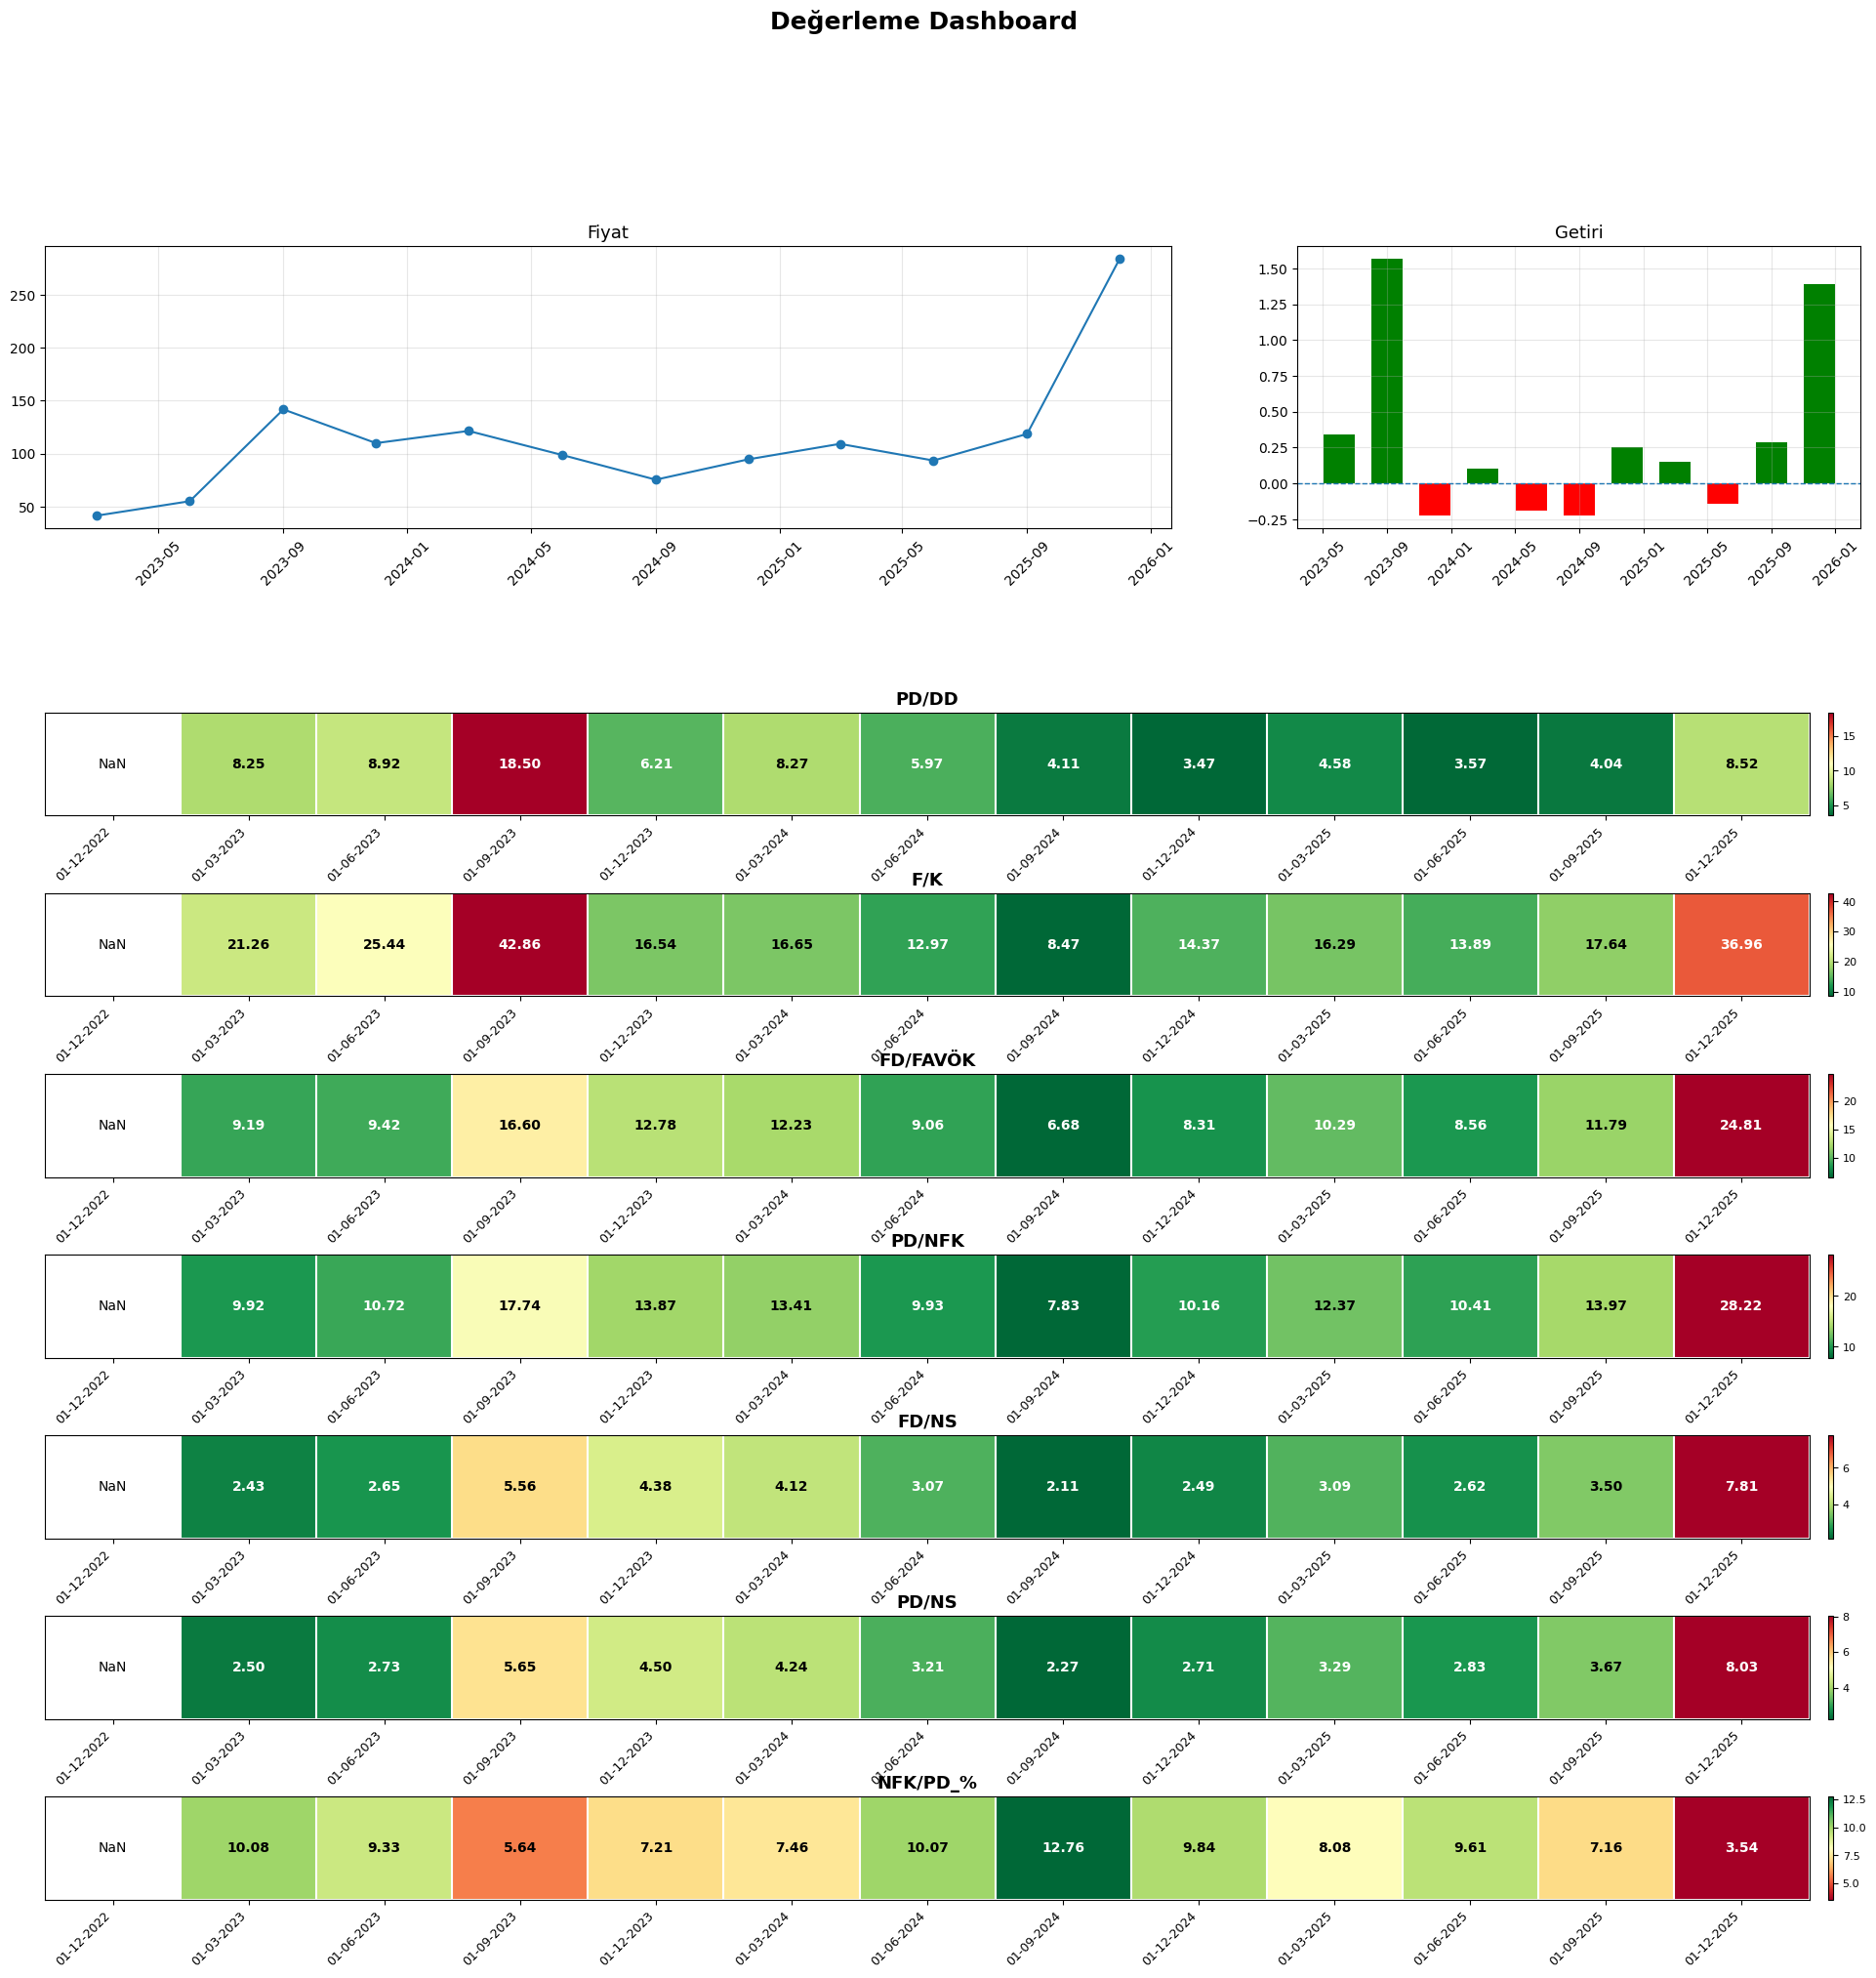


 DEĞERLEME ANALİZİ (SON DÖNEM)

fiyat: 118.70 → 284.00 | Değişim: 165.30 | %139.26 | artmış
getiri: 0.29 → 1.39 | Değişim: 1.11 | %386.68 | artmış
PD/DD: 4.04 → 8.52 | Değişim: 4.47 | %110.69 | artmış
F/K: 17.64 → 36.96 | Değişim: 19.32 | %109.52 | artmış
FD/FAVÖK: 11.79 → 24.81 | Değişim: 13.02 | %110.47 | artmış
PD/NFK: 13.97 → 28.22 | Değişim: 14.24 | %101.91 | artmış
FD/NS: 3.50 → 7.81 | Değişim: 4.31 | %123.31 | artmış
PD/NS: 3.67 → 8.03 | Değişim: 4.36 | %118.97 | artmış
NFK/PD_%: 7.16 → 3.54 | Değişim: -3.61 | %-50.47 | azalmış
****************************************

            fiyat  getiri                 PD                 FD  PD/DD   F/K  \
2022-12-01    NaN     NaN                NaN                NaN    NaN   NaN   
2023-03-01  41.50     NaN  41,417,000,000.00  40,183,368,647.00   8.25 21.26   
2023-06-01  55.20    0.34  55,089,600,761.41  53,549,899,533.41   8.92 25.44   
2023-09-01 141.80    1.57 141,516,403,045.65 139,151,713,902.65  18.50 42.86   
2023-12-01 110.0

Ayrı bir notebookda oluşturulan tahmin edilmiş TUFE verilerini kullanmak için EVET, tekrardan tahmin yapılması için HAYIR yazınız:  EVET



Satış Geliri Tahmini Yapılıyor...

DEBUG: Son Veri: 2025-12-01 | Tahmin Hedefi: 2026-12-01 | Adım Sayısı: 4

MODEL MAE SONUÇLARI



,model,mae,params
0,SARIMA,0.02,"{'order': (1, 1, 0), 'seasonal_order': (0, 0, ..."
1,ARIMA,0.03,"{'order': (1, 0, 3), 'trend': 't'}"
2,TES,0.03,"{'alpha': 0.30000000000000004, 'beta': 0.90000..."
3,SARIMAX_EXOG,0.04,"{'order': (0, 0, 1), 'seasonal_order': (0, 0, ..."


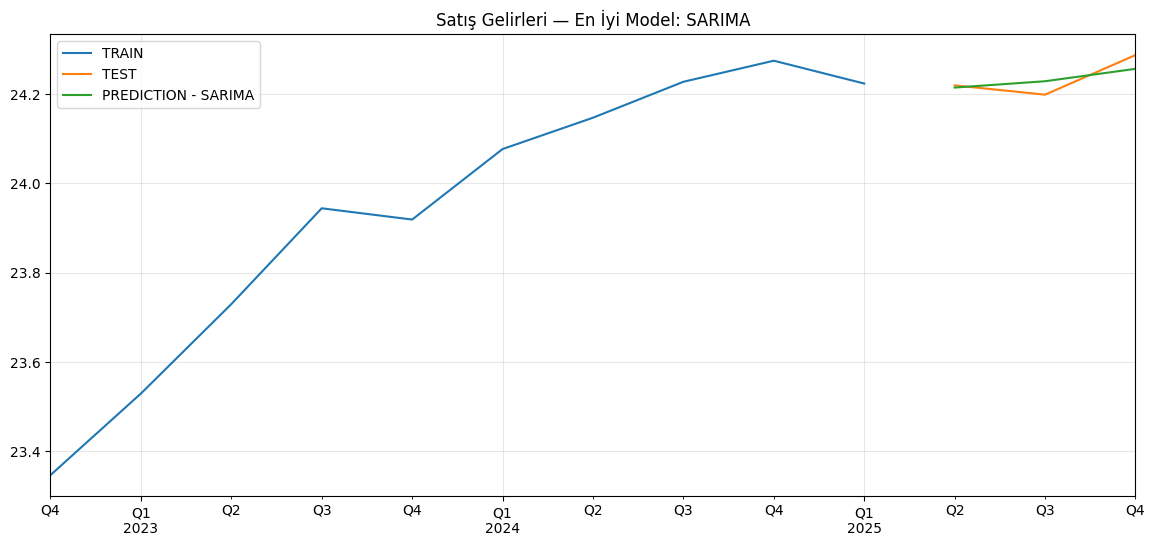


Net Kar Maarjı Tahmini Yapılıyor...

DEBUG: Son Veri: 2025-12-01 | Tahmin Hedefi: 2026-12-01 | Adım Sayısı: 4

MODEL MAE SONUÇLARI



,model,mae,params
0,SARIMA,0.22,"{'order': (1, 1, 0), 'seasonal_order': (0, 0, ..."
1,ARIMA,0.45,"{'order': (1, 1, 0), 'trend': 't'}"
2,TES,0.68,"{'alpha': 0.30000000000000004, 'beta': 0.70000..."
3,SARIMAX_EXOG,0.83,"{'order': (0, 1, 0), 'seasonal_order': (1, 0, ..."


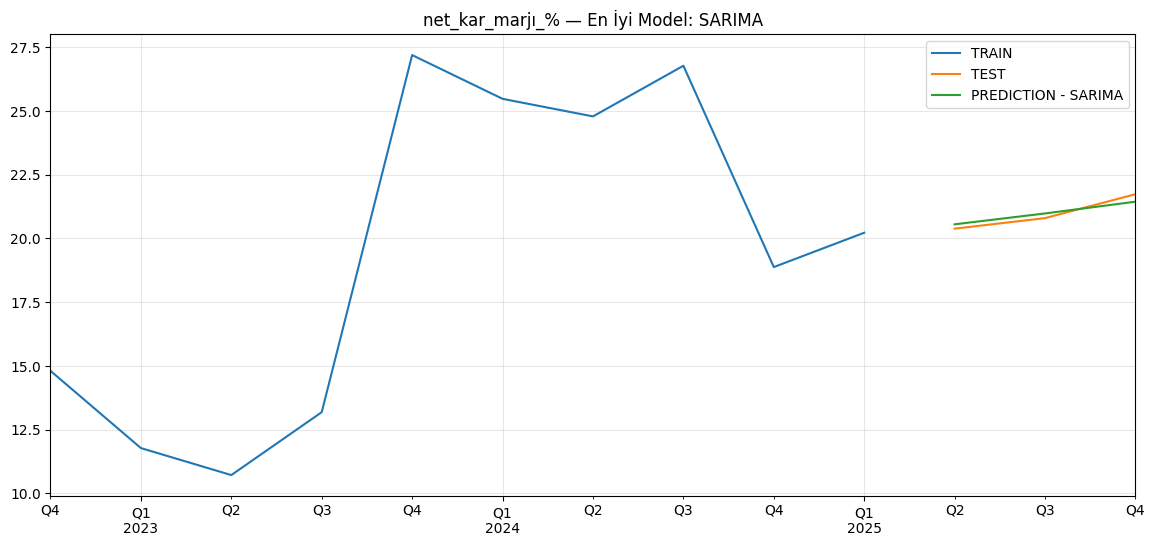


Favök Marjı Tahmini Yapılıyor...

DEBUG: Son Veri: 2025-12-01 | Tahmin Hedefi: 2026-12-01 | Adım Sayısı: 4

MODEL MAE SONUÇLARI



,model,mae,params
0,SARIMA,0.34,"{'order': (0, 1, 0), 'seasonal_order': (0, 1, ..."
1,ARIMA,0.50,"{'order': (1, 0, 0), 'trend': 't'}"
2,TES,0.60,"{'alpha': 0.5000000000000001, 'beta': 0.1, 'ga..."
3,SARIMAX_EXOG,0.99,"{'order': (1, 0, 1), 'seasonal_order': (1, 0, ..."


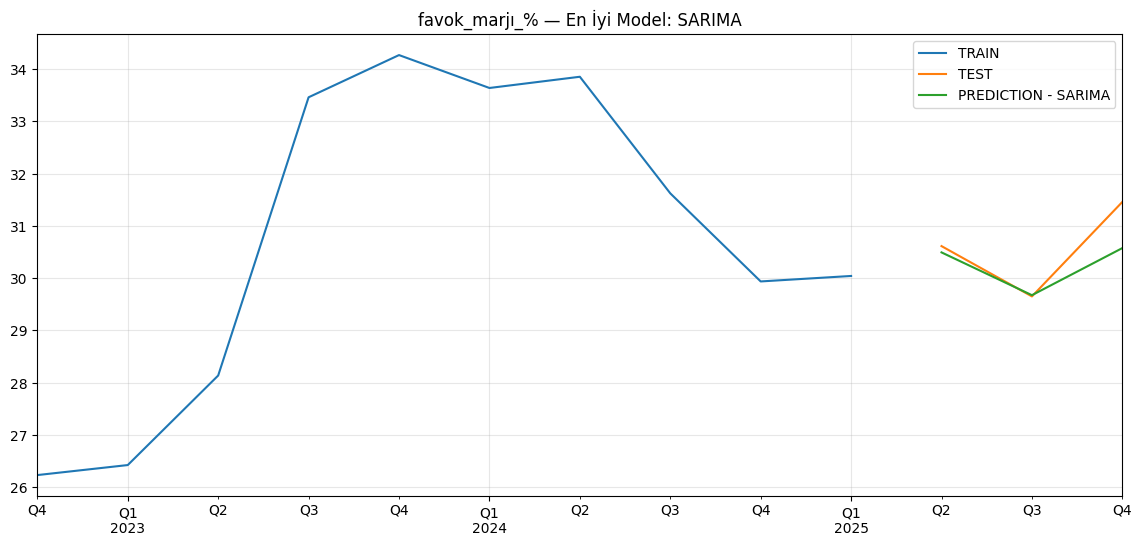


Net Borç / Favök Tahmini Yapılıyor...

DEBUG: Son Veri: 2025-12-01 | Tahmin Hedefi: 2026-12-01 | Adım Sayısı: 4

MODEL MAE SONUÇLARI



,model,mae,params
0,SARIMA,0.03,"{'order': (0, 1, 0), 'seasonal_order': (0, 0, ..."
1,SARIMAX_EXOG,0.06,"{'order': (0, 1, 0), 'seasonal_order': (0, 1, ..."
2,TES,0.13,"{'alpha': 0.1, 'beta': 0.9000000000000001, 'ga..."
3,ARIMA,0.14,"{'order': (0, 0, 1), 'trend': 't'}"


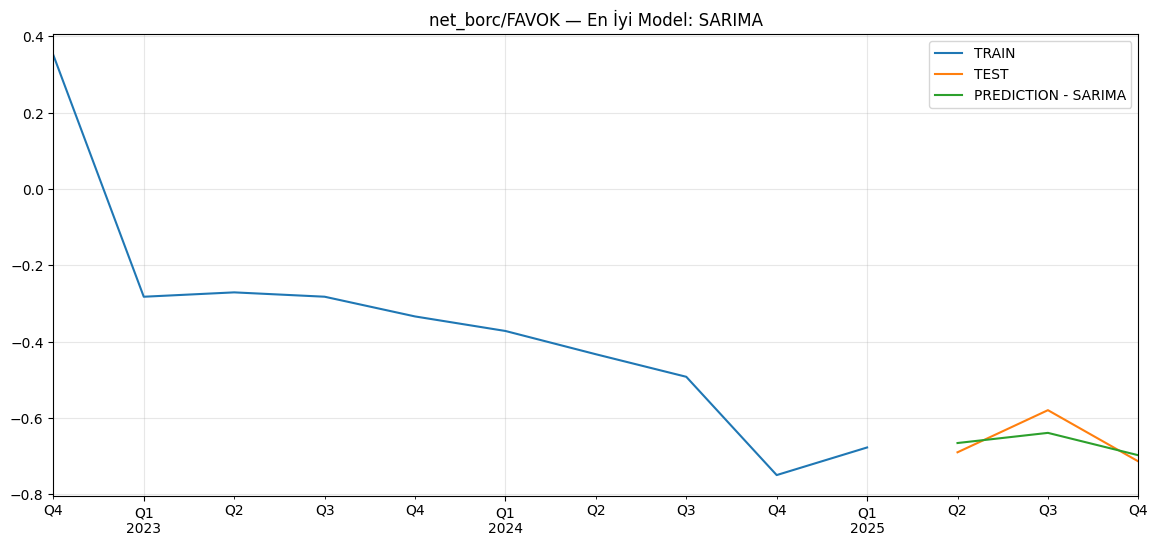


Değerleme tablosu oluşturuluyor...

            Satis_Geliri_tahmin  net_kar_marjı_% Tahmin  favok_marjı_% Tahmin  \
2026-12-01    48,329,946,403.24                   24.26                 57.61   

            net_borc/FAVOK Tahmin   Net_Kar_Tahmini     FAVOK_Tahmini  \
2026-12-01                  -0.32 11,723,581,973.92 27,842,381,611.88   

            Ozkaynak_Tahmini   net_borc Tahmin  F/K Median  PD/DD Median  \
2026-12-01 45,003,715,376.92 -8,909,370,625.24       15.33          4.34   

            FD/FAVÖK Median  PD/NS Median  Tahmini HBK  F/K Fiyat Tahmini  \
2026-12-01             9.68          3.25        11.75             180.10   

            PD/DD Fiyat Tahmini  FD/FAVÖK Fiyat Tahmini  PD/NS Fiyat Tahmini  \
2026-12-01               195.89                  278.84               157.60   

            Ortalama Tahmin  fiyat  iskonto_%   durum  
2026-12-01           203.11 284.00     -28.48  pahalı  

📊 DEĞERLEME ÖZETİ
Güncel Fiyat      : 284.00 TL
Hedef Fiyat       : 203

In [3]:


# -------------------------
# KULLANILAN FONKSİYONLAR
# -------------------------


# -------------------------
# 1 - Gelir tablosu dataframe oluşturma
# -------------------------

def gelir_tablosu(df, ceyrek=False, yillik=False):
    gelir_tab = df[df.columns.tolist()[df.columns.tolist().index("Satış Gelirleri"):]]
    gelir_tab["dönem"] = gelir_tab.index.month
    gelir_tab["yil"] = gelir_tab.index.year
    if ceyrek:
        cols = gelir_tab.select_dtypes(include="number").columns.drop(["dönem", "yil"])
        gelir_tab_cey = gelir_tab.copy()
        mask = gelir_tab_cey["dönem"] != 3
        gelir_tab_cey.loc[mask, cols] = (gelir_tab_cey.groupby("yil")[cols].diff())
        return gelir_tab_cey
    elif yillik:
        gelir_tab_cey = gelir_tab.copy()
        cols = gelir_tab_cey.select_dtypes(include="number").columns.drop(["dönem", "yil"])
        mask = gelir_tab_cey["dönem"] != 3
        gelir_tab_cey.loc[mask, cols] = (gelir_tab_cey.groupby("yil")[cols].diff())
        gelir_tab_yil =gelir_tab_cey.copy()
        gelir_tab_yil[cols] = gelir_tab_cey[cols].rolling(window=4).sum()
        gelir_tab_yil.dropna(inplace=True)
        return gelir_tab_yil
    else:
        return gelir_tab

# -------------------------
# 2 - Gelir tablosu kısmına yıllıklandırma uygulama ve bilanço ile birleştirme
# -------------------------
def bilanco_yillik(df, gelir_tab_yil):
    bilanco = df[df.columns.tolist()[:df.columns.tolist().index("Satış Gelirleri")]]
    bilanco = bilanco.loc[gelir_tab_yil.index,:]
    bilanco = bilanco.loc[:, ~bilanco.columns.duplicated()]
    new_df = bilanco.merge(gelir_tab_yil, how="inner", left_index=True, right_index=True)
    new_df["uzun_vadeli_ticari_borc"] = df.iloc[3:,45].values
    return new_df

# -------------------------
# 3 - Oran ve rasyoların hesaplanması
# -------------------------
def oran_rasyo_hesaplama(new_df, hisse):
    new_df["brüt_kar_marjı_%"] = (new_df["BRÜT KAR (ZARAR)"]/new_df["Satış Gelirleri"]) * 100
    new_df["faaliyet_kar_marjı_%"] = (new_df["Net Faaliyet Kar/Zararı"]/new_df["Satış Gelirleri"])*100
    new_df["favok_marjı_%"] = (new_df["FAVÖK"]/new_df["Satış Gelirleri"])*100
    new_df["net_kar_marjı_%"] = (new_df["Ana Ortaklık Payları"]/new_df["Satış Gelirleri"])*100
    
    new_df["ortalama_toplam_aktifler"] = (
        new_df["TOPLAM VARLIKLAR"] + new_df["TOPLAM VARLIKLAR"].shift(1)
    ) / 2
    
    new_df["aktif_karliligi_%"] = (new_df["Ana Ortaklık Payları"] / new_df["ortalama_toplam_aktifler"])*100
    
    new_df["ortalama_toplam_ozkaynak"] = (
        new_df["  Ana Ortaklığa Ait Özkaynaklar"] + new_df["  Ana Ortaklığa Ait Özkaynaklar"].shift(1)
    ) / 2
    
    new_df["ozkaynak_karliligi_%"] = (new_df["Ana Ortaklık Payları"] / new_df["ortalama_toplam_ozkaynak"])*100
    
    new_df["toplam_borclar"] = new_df["Kısa Vadeli Yükümlülükler"] + new_df["Uzun Vadeli Yükümlülükler"]
    new_df["ozkaynak_borclulugu_%"] = (new_df["toplam_borclar"] / new_df["  Ana Ortaklığa Ait Özkaynaklar"])*100
    
    new_df["aktif_borclulugu_%"] = (new_df["toplam_borclar"] / new_df["TOPLAM VARLIKLAR"]) *100
    
    new_df["faiz_karsilama"] = new_df["FAVÖK"] / new_df["Finansman Giderleri"].abs()
    
    new_df["aktif_devir_hizi"] = new_df["Satış Gelirleri"] / new_df["ortalama_toplam_aktifler"]
    
    new_df["ortalama_ticari_alacak"] = (
        new_df["  Ticari Alacaklar"] + new_df["  Ticari Alacaklar"].shift(1)
    ) / 2
    
    new_df["alacak_devir_hizi"] = new_df["Satış Gelirleri"] / new_df["ortalama_ticari_alacak"]
    
    new_df["ortalama_stok"] = (
        new_df["  Stoklar"] + new_df["  Stoklar"].shift(1)
    ) / 2
    
    new_df["stok_devir_hizi"] = new_df["Satışların Maliyeti (-)"].abs() / new_df["ortalama_stok"]
    
    new_df["ortalama_ticari_borc"] = (
        new_df["  Ticari Borçlar"] + new_df["  Ticari Borçlar"].shift(1)
    ) / 2
    
    new_df["borc_devir_hizi"] = new_df["Satışların Maliyeti (-)"].abs() / new_df["ortalama_ticari_borc"]
    
    new_df["alacak_tahsil_suresi_gun"] = 365 / new_df["alacak_devir_hizi"]
    
    new_df["stok_gun_sayisi"] = 365 / new_df["stok_devir_hizi"]
    
    new_df["borc_odeme_suresi"] = 365 / new_df["borc_devir_hizi"]
    
    new_df["nakit_dongu"] = (new_df["alacak_tahsil_suresi_gun"] + new_df["stok_gun_sayisi"]) - new_df["borc_odeme_suresi"]
    
    new_df["net_isletme_sermayesi"] = new_df["Dönen Varlıklar"] - new_df["Kısa Vadeli Yükümlülükler"]
    
    new_df["cari_oran"] = new_df["Dönen Varlıklar"] / new_df["Kısa Vadeli Yükümlülükler"]
    
    new_df["likitide_oranı"] = (new_df["Dönen Varlıklar"] - new_df["  Stoklar"]) / new_df["Kısa Vadeli Yükümlülükler"]
    
    new_df["nakit_oranı"] = new_df["  Nakit ve Nakit Benzerleri"] / new_df["Kısa Vadeli Yükümlülükler"]
    
    new_df["hbk"] = new_df["Ana Ortaklık Payları"] / new_df["  Ödenmiş Sermaye"]
    
    new_df["net_borc"] = (new_df["  Finansal Borçlar"] + new_df["  Diğer Finansal Yükümlülükler"] + new_df["uzun_vadeli_ticari_borc"]) - (new_df["  Nakit ve Nakit Benzerleri"] + new_df["  Finansal Yatırımlar"])
    
    new_df["net_borc/FAVOK"] = new_df["net_borc"] / new_df["FAVÖK"]

    new_df = new_df.copy()
    new_df.index = pd.to_datetime(new_df.index)
    new_df = new_df.sort_index()
    sirket = hisse + ".IS"
    
    prices_raw = yf.download(
        sirket,
        start=new_df.index.min() - pd.Timedelta(days=10),
        end=new_df.index.max() + pd.Timedelta(days=10),
        auto_adjust=False,
        progress=False,
        multi_level_index=False
    )
    
    prices = prices_raw[["Close", "Adj Close"]].rename(
        columns={
            "Close": "fiyat",
            "Adj Close": "duzeltilmis_fiyat"
        }
    )
    
    df = pd.merge_asof(
        new_df.sort_index(),
        prices.sort_index(),
        left_index=True,
        right_index=True,
        direction="backward"
    )
    
    last_price_raw = yf.download(
        sirket,
        period="1d",
        interval="1d",
        progress=False,
        auto_adjust=False,
        multi_level_index=False
    )

    if not last_price_raw.empty:
        guncel_fiyat = last_price_raw["Close"].iloc[-1]

        if "Adj Close" in last_price_raw.columns:
            guncel_duzeltilmis_fiyat = last_price_raw["Adj Close"].iloc[-1]
        else:
            guncel_duzeltilmis_fiyat = guncel_fiyat

        df.loc[df.index[-1], "fiyat"] = guncel_fiyat
        df.loc[df.index[-1], "duzeltilmis_fiyat"] = guncel_duzeltilmis_fiyat
    
    df["getiri"] = df["duzeltilmis_fiyat"].pct_change()

    df["PD"] = df["  Ödenmiş Sermaye"] * df["fiyat"]
    df["FD"] = df["PD"] + df["net_borc"]
    df["PD/DD"] = df["PD"] / df["  Ana Ortaklığa Ait Özkaynaklar"]
    df["F/K"] = df["fiyat"] / df["hbk"]
    df["FD/FAVÖK"] = df["FD"] / df["FAVÖK"]
    df["PD/NFK"] = df["PD"] / df["Net Faaliyet Kar/Zararı"]
    df["FD/NS"] = df["FD"] / df["Satış Gelirleri"]
    df["NFK/PD_%"] = (df["Net Faaliyet Kar/Zararı"] / df["PD"])*100
    df["PD/NS"] = df["PD"] / df["Satış Gelirleri"]

    # negatifleri NaN yap
    degerleme_cols = ["PD/DD", "F/K", "FD/FAVÖK", "PD/NFK", "FD/NS", "NFK/PD_%", "PD/NS"]
    df[degerleme_cols] = df[degerleme_cols].mask(df[degerleme_cols] < 0, np.nan)

    buyume_adayları = ["Satış Gelirleri", "BRÜT KAR (ZARAR)", "FAALİYET KARI (ZARARI)", "FAVÖK", "DÖNEM KARI (ZARARI)",
                       "TOPLAM VARLIKLAR", "Özkaynaklar", "  Nakit ve Nakit Benzerleri",
                       "Duran Varlıklar", "Dönen Varlıklar", "  Stoklar", "  Ticari Alacaklar",
                       "  Ticari Borçlar", "Kısa Vadeli Yükümlülükler", "Uzun Vadeli Yükümlülükler",
                       "Serbest Nakit Akım", " İşletme Faaliyetlerinden Kaynaklanan Net Nakit"]
    for col in buyume_adayları:
        df[f"{col}_qoq_%"] = df[col].pct_change(1)
        df[f"{col}_yoy_%"] = df[col].pct_change(4)

    return df

# -------------------------
# 4 - EVDS'den makro ekonomi verilerini alma
# -------------------------

def TUFE_alma(df, api_key):
    start_date = df.index[0]
    end_date = df.index[-1]

    start_date = start_date.strftime("%d-%m-%Y")
    end_date = end_date.strftime("%d-%m-%Y")

    evds = evdsAPI(api_key)
    makro_data = evds.get_data(['TP.FG.J0','TP.TUFE1YI.T1'],startdate=start_date,enddate=end_date, frequency = 5)
    makro_data.columns = ["Tarih", "TUFE", "UFE"]
    makro_data["log_TUFE"] = np.log1p(makro_data["TUFE"])
    makro_data["log_UFE"] = np.log1p(makro_data["UFE"])
    makro_data["tufe_yillik"] = makro_data["TUFE"].pct_change(4)
    makro_data["ufe_yillik"] = makro_data["UFE"].pct_change(4)
    makro_data["ufe_tufe_spread"] = makro_data["log_UFE"] - makro_data["log_TUFE"]
    makro_data.set_index("Tarih", inplace=True)
    makro_data.index = pd.to_datetime(makro_data.index, format="%Y-%m")
    return makro_data

# -------------------------
# 5 - EVDS'den makro ekonomi verilerini alma. TUFE tahmini yapılacaksa kullanılır. Başlangıç tarihi belirlidir.
# -------------------------
def TUFE_alma_2(df, api_key):
    start_date = "01-12-2019"
    end_date = df.index[-1]

    #start_date = start_date.strftime("%d-%m-%Y")
    end_date = end_date.strftime("%d-%m-%Y")

    evds = evdsAPI(api_key)
    makro_data = evds.get_data(['TP.FG.J0','TP.TUFE1YI.T1'],startdate=start_date,enddate=end_date, frequency = 5)
    makro_data.columns = ["Tarih", "TUFE", "UFE"]
    makro_data["log_TUFE"] = np.log1p(makro_data["TUFE"])
    makro_data["log_UFE"] = np.log1p(makro_data["UFE"])
    makro_data["tufe_yillik"] = makro_data["TUFE"].pct_change(4)
    makro_data["ufe_yillik"] = makro_data["UFE"].pct_change(4)
    makro_data["ufe_tufe_spread"] = makro_data["log_UFE"] - makro_data["log_TUFE"]
    makro_data.set_index("Tarih", inplace=True)
    makro_data.index = pd.to_datetime(makro_data.index, format="%Y-%m")
    return makro_data

# -------------------------
# 4 - Değişim yüzdelerinin zaman serisi grafikleri
# -------------------------

def degisim_plot(df):
    df2 = df.copy()
    
    qoq_cols = [col for col in df2.columns if "_qoq_" in col]
    yoy_cols = [col for col in df2.columns if "_yoy_" in col]

    metrics = [col.replace("_qoq_%", "") for col in qoq_cols]

    # subplot
    n = len(metrics)
    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
    axes = axes.flatten()

    print("\nDEĞİŞİM ANALİZİ (SON DÖNEM)\n")

    THRESHOLD = 0.02  # %2 altını yatay say

    for i, metric in enumerate(metrics):
        ax = axes[i]

        qoq_col = metric + "_qoq_%"
        yoy_col = metric + "_yoy_%"

        ax.plot(df2.index, df2[qoq_col], marker="o", label="QoQ %")
        ax.plot(df2.index, df2[yoy_col], marker="o", label="YoY %")

        ax.set_title(metric, fontsize=10)
        ax.axhline(0, linestyle="--", linewidth=1)
        ax.tick_params(axis='x', rotation=90)
        ax.legend()
        ax.grid(True)

        
        qoq_series = df2[qoq_col].dropna()
        yoy_series = df2[yoy_col].dropna()

        if len(qoq_series) >= 2:
            last_qoq = qoq_series.iloc[-1]
            prev_qoq = qoq_series.iloc[-2]
            diff_qoq = last_qoq - prev_qoq

            if diff_qoq > THRESHOLD:
                trend_qoq = "hızlanarak artıyor"
            elif diff_qoq < -THRESHOLD:
                trend_qoq = "yavaşlıyor / düşüyor"
            else:
                trend_qoq = "yatay"

        else:
            trend_qoq = "yetersiz veri"

        if len(yoy_series) >= 2:
            last_yoy = yoy_series.iloc[-1]
        else:
            last_yoy = np.nan

        print(
            f"{metric}:\n"
            f"  QoQ: {prev_qoq:.2%} → {last_qoq:.2%} | Trend: {trend_qoq}\n"
            f"  YoY: {last_yoy:.2%}\n"
        )

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# -------------------------
# 6 - Kar marjlarının zaman serisi grafikleri
# -------------------------
def karlılık_plot(df):
    df2 = df.copy()

    pct_cols = [col for col in df2.columns if "%" in col]
    value_cols = [col for col in df2.columns if "%" not in col]

    all_cols = df2.columns.tolist()

    # subplot
    n = len(all_cols)
    cols=3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
    axes = axes.flatten()

    THRESHOLD = 0.2   # %0.2 altını "yatay" say

    print("\n ORAN ANALİZİ (SON DÖNEM):\n")

    for i, col in enumerate(all_cols):
        ax = axes[i]
    
        if col in pct_cols:
            ax.plot(df2.index, df2[col], marker="o")
            ax.axhline(0, linestyle="--", linewidth=1)
            ax.set_ylabel("%")

            # Otomatik Yorum
            series = df[col].dropna()

            if len(series) >= 2:
                last = series.iloc[-1]
                prev = series.iloc[-2]
                diff = last - prev
                
                if diff > THRESHOLD:
                    trend = "artmış"
                elif diff < -THRESHOLD:
                    trend = "düşmüş"
                else:
                    trend = "yatay"
                print(f"{col}: {prev:.2f} → {last:.2f} | Değişim: {diff:.2f} → {trend}")
        else:
            ax.bar(df2.index, df2[col], width=60)
            ax.set_ylabel("Tutar")
    
        ax.set_title(col, fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis="x", rotation=45)
    
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

# -------------------------
# 7 - Bilanço dengesinin görselleştirilmesi
# -------------------------
def denge_plot(df):
    df2 = df.copy()
    main_line_cols = ["TOPLAM VARLIKLAR", "Özkaynaklar", "toplam_borclar"]
    
    # Ayrı subplotta gösterilecek kolonlar
    other_cols = [col for col in df2.columns if col not in main_line_cols]
    
    # Son dönem değişimlerini yazdır
    print("\nSON DÖNEM DEĞİŞİM ANALİZİ\n")
    
    for col in df2.columns:
        s = df2[col].dropna()
        if len(s) >= 2:
            prev = s.iloc[-2]
            last = s.iloc[-1]
            diff = last - prev
            pct_change = (diff / prev * 100) if prev != 0 else float("nan")
    
            if diff > 0:
                print(f"{col}, son dönemde {prev:,.0f} seviyesinden {last:,.0f} seviyesine yükselmiştir. "
                      f"Artış tutarı {diff:,.0f}, artış oranı %{pct_change:.2f}.")
            elif diff < 0:
                print(f"{col}, son dönemde {prev:,.0f} seviyesinden {last:,.0f} seviyesine gerilemiştir. "
                      f"Azalış tutarı {abs(diff):,.0f}, değişim oranı %{abs(pct_change):.2f}.")
            else:
                print(f"{col}, son dönemde değişim göstermemiştir ve {last:,.0f} seviyesinde kalmıştır.")
    
    # ---------- 1) Ana tek plot ----------
    plt.figure(figsize=(12, 6))
    
    for col in main_line_cols:
        plt.plot(df2.index, df2[col], marker="o", label=col)
    
    plt.title("Toplam Varlıklar - Özkaynaklar - Toplam Borçlar")
    plt.xlabel("Tarih")
    plt.ylabel("Tutar")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # ---------- 2) Diğerleri subplot ----------
    n = len(other_cols)
    cols = 3
    rows = math.ceil(n / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
    axes = axes.flatten()
    
    for i, col in enumerate(other_cols):
        ax = axes[i]
    
        if col == "net_isletme_sermayesi":
            ax.plot(df2.index, df2[col], marker="o")
            ax.axhline(0, linestyle="--", linewidth=1)
        else:
            ax.bar(df2.index, df2[col], width=60)
    
        ax.set_title(col, fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis="x", rotation=45)
        ax.ticklabel_format(style="plain", axis="y")
    
    # Boş eksenleri kaldır
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

# -------------------------
# 8 - Likitide durumunun görselleştirilmesi
# -------------------------
    
def liktide_plot(df):
    df2 = df.copy()
    
    
    # SON DÖNEM RAPORU
    
    print("\nLİKİDİTE & BORÇ ANALİZİ (SON DÖNEM)\n")
    
    for col in df2.columns:
        s = df2[col].dropna()
        if len(s) >= 2:
            prev = s.iloc[-2]
            last = s.iloc[-1]
            diff = last - prev
            pct = (diff / prev * 100) if prev != 0 else float("nan")
    
            if diff > 0:
                print(f"{col}: {prev:,.2f} → {last:,.2f} | ↑ Artış (%{pct:.2f})")
            elif diff < 0:
                print(f"{col}: {prev:,.2f} → {last:,.2f} | ↓ Azalış (%{abs(pct):.2f})")
            else:
                print(f"{col}: Değişim yok ({last:,.2f})")
    
    
    # SUBPLOT
    fig, axes = plt.subplots(4, 1, figsize=(14, 12))
    
    # Likidite oranları (line)
    axes[0].plot(df2.index, df2["cari_oran"], marker="o", label="Cari Oran")
    axes[0].plot(df2.index, df2["likitide_oranı"], marker="o", label="Likidite Oranı")
    axes[0].plot(df2.index, df2["nakit_oranı"], marker="o", label="Nakit Oranı")
    
    axes[0].set_title("Likidite Oranları")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(1, linestyle="--", linewidth=1)  # kritik seviye
    
    # Nakit vs Net Borç (bar)
    axes[1].bar(df2.index, df2["  Nakit ve Nakit Benzerleri"], label="Nakit", width=60)
    
    axes[1].set_title("Nakit ve Nakit Benzerleri")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].ticklabel_format(style="plain", axis="y")

    axes[2].bar(df2.index, df2["net_borc"], label="Net Borç", width=60)
    axes[2].set_title("Net Borç")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    axes[2].ticklabel_format(style="plain", axis="y")
    
    # Net Borç / FAVÖK (line)
    axes[3].plot(df2.index, df2["net_borc/FAVOK"], marker="o")
    
    axes[3].set_title("Net Borç / FAVÖK")
    axes[3].grid(True, alpha=0.3)
    axes[3].axhline(0, linestyle="--", linewidth=1)
    
    # X ekseni düzeni
    for ax in axes:
        ax.tick_params(axis="x", rotation=45)
    
    plt.tight_layout()
    plt.show()

# -------------------------
# 9 - Nakit döngüsünün görselleştirilmesi
# -------------------------

def yeterlik_plot(df):
    df2 = df.copy()
    
    # Aynı plotta gösterilecek gün bazlı metrikler
    main_line_cols = [
        "alacak_tahsil_suresi_gun",
        "stok_gun_sayisi",
        "borc_odeme_suresi",
        "nakit_dongu"
    ]
    
    # Diğer subplot metrikleri
    other_cols = [col for col in df2.columns if col not in main_line_cols]
    
    # SON DÖNEM RAPORU
    print("\n FAALİYET VERİMLİLİĞİ / YETERLİLİK ANALİZİ (SON DÖNEM)\n")
    
    for col in df2.columns:
        s = df2[col].dropna()
        if len(s) >= 2:
            prev = s.iloc[-2]
            last = s.iloc[-1]
            diff = last - prev
            pct_change = (diff / prev * 100) if prev != 0 else float("nan")
    
            if diff > 0:
                print(
                    f"{col}: {prev:.2f} → {last:.2f} | "
                    f"Artış: {diff:.2f} (%{pct_change:.2f})"
                )
            elif diff < 0:
                print(
                    f"{col}: {prev:.2f} → {last:.2f} | "
                    f"Azalış: {abs(diff):.2f} (%{abs(pct_change):.2f})"
                )
            else:
                print(f"{col}: Değişim yok ({last:.2f})")
    
    # 1) Gün bazlı metrikler tek plot
    plt.figure(figsize=(13, 6))
    
    for col in main_line_cols:
        plt.plot(df2.index, df2[col], marker="o", label=col)
    
    plt.title("Tahsilat / Stok / Borç Ödeme / Nakit Döngüsü")
    plt.xlabel("Tarih")
    plt.ylabel("Gün")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # 2) Diğer metrikler subplot
    n = len(other_cols)
    cols = 2
    rows = math.ceil(n / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
    axes = axes.flatten()
    
    for i, col in enumerate(other_cols):
        ax = axes[i]
        ax.plot(df2.index, df2[col], marker="o")
        ax.set_title(col, fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis="x", rotation=45)
    
    # Fazla eksenleri kaldır
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

# -------------------------
# 10 - Nakit akımlarının zaman serisi grafikleri
# -------------------------

def plot_nakit_akimi(df_nakit):
    df = df_nakit.copy()

    # Kolon ayrımı
    flow_cols = [
        " İşletme Faaliyetlerinden Kaynaklanan Net Nakit",
        "Serbest Nakit Akım",
        " Yatırım Faaliyetlerinden Kaynaklanan Nakit",
        "Finansman Faaliyetlerden Kaynaklanan Nakit",
        "Nakit ve Benzerlerindeki Değişim"
    ]

    stock_cols = [
        "Dönem Başı Nakit Değerler",
        "Dönem Sonu Nakit"
    ]

    all_cols = df.columns.tolist()

    
    # SON DÖNEM RAPORU
    
    print("\n NAKİT AKIM ANALİZİ (SON DÖNEM)\n")

    for col in all_cols:
        s = df[col].dropna()
        if len(s) >= 2:
            prev = s.iloc[-2]
            last = s.iloc[-1]
            diff = last - prev
            pct = (diff / abs(prev) * 100) if prev != 0 else float("nan")

            if diff > 0:
                print(f"{col}: {prev:,.0f} → {last:,.0f} | ↑ Artış (%{pct:.2f})")
            elif diff < 0:
                print(f"{col}: {prev:,.0f} → {last:,.0f} | ↓ Azalış (%{abs(pct):.2f})")
            else:
                print(f"{col}: Değişim yok")

    # SUBPLOT

    n = len(all_cols)
    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(all_cols):
        ax = axes[i]

        if col in flow_cols:
            ax.plot(df.index, df[col], marker="o")
            ax.axhline(0, linestyle="--", linewidth=1)
        else:
            ax.bar(df.index, df[col], width=60)

        ax.set_title(col, fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis="x", rotation=45)
        ax.ticklabel_format(style="plain", axis="y")

    # boşları sil
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# -------------------------
# 11 - Çarpanların zaman serisi grafikleri
# -------------------------

def plot_degerleme_dashboard(df_degerleme):
    df = df_degerleme.copy()

    ratio_cols = ["PD/DD", "F/K", "FD/FAVÖK", "PD/NFK", "FD/NS", "PD/NS", "NFK/PD_%"]
    period_labels = df.index.strftime("%d-%m-%Y")

    # Figure layout
    
    fig = plt.figure(figsize=(24, 22))
    outer = fig.add_gridspec(
        2, 1,
        height_ratios=[1, 4.2],
        hspace=0.25
    )

    # Üst bölüm: fiyat + getiri
    top = outer[0].subgridspec(1, 2, width_ratios=[2, 1], wspace=0.15)
    ax_price = fig.add_subplot(top[0, 0])
    ax_return = fig.add_subplot(top[0, 1])

    # Alt bölüm: heatmapler alt alta büyük
    bottom_rows = len(ratio_cols)
    bottom = outer[1].subgridspec(bottom_rows, 1, hspace=0.75)

    heat_axes = [
        fig.add_subplot(bottom[i, 0])
        for i in range(len(ratio_cols))
    ]

    # Fiyat grafiği
    
    ax_price.plot(df.index, df["fiyat"], marker="o")
    ax_price.set_title("Fiyat", fontsize=13)
    ax_price.grid(True, alpha=0.3)
    ax_price.tick_params(axis="x", rotation=45)

    # Getiri grafiği
    
    returns = df["getiri"].copy()
    bar_colors = ["green" if pd.notna(x) and x >= 0 else "red" for x in returns]

    ax_return.bar(df.index, returns, color=bar_colors, width=60)
    ax_return.axhline(0, linestyle="--", linewidth=1)
    ax_return.set_title("Getiri", fontsize=13)
    ax_return.grid(True, alpha=0.3)
    ax_return.tick_params(axis="x", rotation=45)

    # Heatmap helper
    
    cmap_good_low = plt.cm.get_cmap("RdYlGn_r")  # düşük değer iyi
    cmap_good_high = plt.cm.get_cmap("RdYlGn")   # yüksek değer iyi

    def draw_single_row_heatmap(ax, series, title, high_is_good=False):
        vals = series.values.astype(float).reshape(1, -1)

        if np.all(np.isnan(vals)):
            ax.set_title(title, fontsize=13)
            ax.axis("off")
            return

        vmin = np.nanmin(vals)
        vmax = np.nanmax(vals)

        if vmin == vmax:
            vmin -= 1
            vmax += 1

        cmap = cmap_good_high if high_is_good else cmap_good_low
        norm = colors.Normalize(vmin=vmin, vmax=vmax)

        img = ax.imshow(vals, aspect="auto", cmap=cmap, norm=norm)

        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_yticks([])
        ax.set_xticks(np.arange(len(series)))
        ax.set_xticklabels(period_labels, rotation=45, ha="right", fontsize=9)

        for j, v in enumerate(series.values):
            if pd.notna(v):
                rgba = cmap(norm(v))
                luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
                text_color = "black" if luminance > 0.6 else "white"

                ax.text(
                    j, 0, f"{v:.2f}",
                    ha="center",
                    va="center",
                    color=text_color,
                    fontsize=10,
                    fontweight="bold"
                )
            else:
                ax.text(
                    j, 0, "NaN",
                    ha="center",
                    va="center",
                    color="black",
                    fontsize=10
                )

        ax.set_xticks(np.arange(-0.5, len(series), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 1, 1), minor=True)

        ax.grid(
            which="minor",
            color="white",
            linestyle="-",
            linewidth=1.5
        )

        ax.tick_params(which="minor", bottom=False, left=False)

        cbar = plt.colorbar(img, ax=ax, fraction=0.018, pad=0.01)
        cbar.ax.tick_params(labelsize=8)

    # Heatmapler
    
    for ax, col in zip(heat_axes, ratio_cols):
        high_is_good = col == "NFK/PD_%"
        draw_single_row_heatmap(
            ax=ax,
            series=df[col],
            title=col,
            high_is_good=high_is_good
        )

    plt.suptitle("Değerleme Dashboard", fontsize=18, fontweight="bold", y=0.99)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


    # Son dönem değişim raporu

    print("\n DEĞERLEME ANALİZİ (SON DÖNEM)\n")

    for col in ["fiyat", "getiri"] + ratio_cols:
        if col not in df.columns:
            continue

        s = df[col].dropna()

        if len(s) >= 2:
            prev = s.iloc[-2]
            last = s.iloc[-1]
            diff = last - prev
            pct_change = (diff / abs(prev) * 100) if prev != 0 else np.nan

            if diff > 0:
                direction = "artmış"
            elif diff < 0:
                direction = "azalmış"
            else:
                direction = "değişmemiş"

            print(
                f"{col}: {prev:.2f} → {last:.2f} | "
                f"Değişim: {diff:.2f} | "
                f"%{pct_change:.2f} | {direction}"
            )

    return df

# -------------------------
# 11 - Hisse skoru hesaplama
# -------------------------

def financial_scorecard(df):
    data = df.copy().sort_index()
    last = data.iloc[-1]

    def safe_get(col):
        return last[col] if col in data.columns and pd.notna(last[col]) else np.nan

    def linear_score(x, low, high, reverse=False):
        if pd.isna(x):
            return np.nan
        if low == high:
            return 50.0

        score = (x - low) / (high - low) * 100
        score = np.clip(score, 0, 100)

        if reverse:
            score = 100 - score

        return float(score)

    def band_score(x, low_bad, low_good, high_good, high_bad):
        """
        Ortadaki bant en iyi.
        low_bad < low_good <= high_good < high_bad
        """
        if pd.isna(x):
            return np.nan

        if low_good <= x <= high_good:
            return 100.0
        elif x < low_good:
            return linear_score(x, low_bad, low_good, reverse=False)
        else:
            return linear_score(x, high_good, high_bad, reverse=True)

    def avg_scores(score_dict):
        vals = [v for v in score_dict.values() if pd.notna(v)]
        return round(float(np.mean(vals)), 2) if vals else np.nan

    # -------------------------
    # 1) BÜYÜME
    # -------------------------
    growth_scores = {
        "sales_yoy": linear_score(safe_get("Satış Gelirleri_yoy_%"), -0.20, 0.50),
        "ebitda_yoy": linear_score(safe_get("FAVÖK_yoy_%"), -0.20, 0.50),
        "net_income_yoy": linear_score(safe_get("DÖNEM KARI (ZARARI)_yoy_%"), -0.30, 0.60),
        "equity_yoy": linear_score(safe_get("Özkaynaklar_yoy_%"), -0.10, 0.40),
        "fcf_yoy": linear_score(safe_get("Serbest Nakit Akım_yoy_%"), -0.50, 0.80),
    }
    growth_score = avg_scores(growth_scores)

    # -------------------------
    # 2) KARLILIK
    # -------------------------
    profitability_scores = {
        "gross_margin": linear_score(safe_get("brüt_kar_marjı_%"), 0, 25),
        "operating_margin": linear_score(safe_get("faaliyet_kar_marjı_%"), -5, 20),
        "net_margin": linear_score(safe_get("net_kar_marjı_%"), -5, 20),
        "roa": linear_score(safe_get("aktif_karliligi_%"), 0, 20),
        "roe": linear_score(safe_get("ozkaynak_karliligi_%"), 0, 30),
        "interest_cover": linear_score(safe_get("faiz_karsilama"), 0, 10),
    }
    profitability_score = avg_scores(profitability_scores)

    # -------------------------
    # 3) BİLANÇO SAĞLIĞI
    # -------------------------
    balance_scores = {
        "equity_ratio_proxy": linear_score(100 - safe_get("aktif_borclulugu_%"), 20, 80),
        "debt_to_equity": linear_score(safe_get("ozkaynak_borclulugu_%"), 0, 300, reverse=True),
        "net_debt_ebitda": linear_score(safe_get("net_borc/FAVOK"), -2, 4, reverse=True),
    }
    balance_score = avg_scores(balance_scores)

    # -------------------------
    # 4) LİKİDİTE
    # -------------------------
    liquidity_scores = {
        "current_ratio": band_score(safe_get("cari_oran"), 0.5, 1.2, 2.0, 3.5),
        "quick_ratio": band_score(safe_get("likitide_oranı"), 0.4, 0.8, 1.5, 3.0),
        "cash_ratio": linear_score(safe_get("nakit_oranı"), 0.1, 1.0),
        "nwc": linear_score(safe_get("net_isletme_sermayesi"), 0, max(1, safe_get("net_isletme_sermayesi"))),
    }
    liquidity_score = avg_scores(liquidity_scores)

    # -------------------------
    # 5) FAALİYET VERİMLİLİĞİ
    # -------------------------
    efficiency_scores = {
        "asset_turnover": linear_score(safe_get("aktif_devir_hizi"), 0.5, 3.0),
        "receivable_days": linear_score(safe_get("alacak_tahsil_suresi_gun"), 10, 90, reverse=True),
        "inventory_days": linear_score(safe_get("stok_gun_sayisi"), 5, 120, reverse=True),
        "payable_days": linear_score(safe_get("borc_odeme_suresi"), 10, 90),   # daha uzun bazen olumlu
        "cash_cycle": linear_score(safe_get("nakit_dongu"), 0, 60, reverse=True),
    }
    efficiency_score = avg_scores(efficiency_scores)

    # -------------------------
    # 6) NAKİT AKIŞI KALİTESİ
    # -------------------------
    cfo = safe_get("İşletme Faaliyetlerinden Kaynaklanan Net Nakit")
    fcf = safe_get("Serbest Nakit Akım")
    net_income = safe_get("DÖNEM KARI (ZARARI)")
    ebitda = safe_get("FAVÖK")

    cfo_to_income = np.nan
    fcf_to_ebitda = np.nan

    if pd.notna(cfo) and pd.notna(net_income) and net_income != 0:
        cfo_to_income = cfo / net_income
    if pd.notna(fcf) and pd.notna(ebitda) and ebitda != 0:
        fcf_to_ebitda = fcf / ebitda

    cashflow_scores = {
        "cfo_level": linear_score(cfo, 0, max(1, cfo)) if pd.notna(cfo) else np.nan,
        "fcf_level": linear_score(fcf, 0, max(1, fcf)) if pd.notna(fcf) else np.nan,
        "cfo_to_income": linear_score(cfo_to_income, 0.5, 1.5),
        "fcf_to_ebitda": linear_score(fcf_to_ebitda, 0.1, 0.8),
        "cash_change": linear_score(safe_get("Nakit ve Benzerlerindeki Değişim"), 0, max(1, safe_get("Nakit ve Benzerlerindeki Değişim")))
    }
    cashflow_score = avg_scores(cashflow_scores)

    # -------------------------
    # 7) DEĞERLEME
    # -------------------------
    valuation_scores = {
        "pd_dd": linear_score(safe_get("PD/DD"), 0.5, 3.0, reverse=True),
        "pe": linear_score(safe_get("F/K"), 3, 25, reverse=True),
        "ev_ebitda": linear_score(safe_get("FD/FAVÖK"), 4, 20, reverse=True),
        "pd_nfk": linear_score(safe_get("PD/NFK"), 0, 60, reverse=True),
        "fd_ns": linear_score(safe_get("FD/NS"), 0.2, 2.0, reverse=True),
        "pd_ns": linear_score(safe_get("PD/NS"), 0.2, 2.0, reverse=True),
        "fcf_yield": linear_score(safe_get("NFK/PD_%"), 0, 10),
    }
    valuation_score = avg_scores(valuation_scores)

    # -------------------------
    # 8) MOMENTUM
    # -------------------------
    momentum_scores = {
        "price_return": linear_score(safe_get("getiri"), -0.30, 0.60),
        "sales_qoq": linear_score(safe_get("Satış Gelirleri_qoq_%"), -0.10, 0.20),
        "ebitda_qoq": linear_score(safe_get("FAVÖK_qoq_%"), -0.20, 0.30),
        "net_income_qoq": linear_score(safe_get("DÖNEM KARI (ZARARI)_qoq_%"), -0.30, 0.50),
    }
    momentum_score = avg_scores(momentum_scores)

    # -------------------------
    # AĞIRLIKLAR
    # -------------------------
    category_scores = {
        "Büyüme": growth_score,
        "Karlılık": profitability_score,
        "Bilanço": balance_score,
        "Likidite": liquidity_score,
        "Verimlilik": efficiency_score,
        "Nakit Akışı": cashflow_score,
        "Değerleme": valuation_score,
        "Momentum": momentum_score,
    }

    weights = {
        "Büyüme": 0.15,
        "Karlılık": 0.20,
        "Bilanço": 0.15,
        "Likidite": 0.10,
        "Verimlilik": 0.10,
        "Nakit Akışı": 0.15,
        "Değerleme": 0.10,
        "Momentum": 0.05,
    }

    weighted_values = []
    used_weights = []

    for k, v in category_scores.items():
        if pd.notna(v):
            weighted_values.append(v * weights[k])
            used_weights.append(weights[k])

    total_score = np.sum(weighted_values) / np.sum(used_weights) if used_weights else np.nan
    total_score = round(float(total_score), 2) if pd.notna(total_score) else np.nan

    # -------------------------
    # SINIFLANDIRMA
    # -------------------------
    if pd.isna(total_score):
        signal = "Skor hesaplanamadı"
    elif total_score >= 80:
        signal = "Çok Güçlü"
    elif total_score >= 65:
        signal = "Güçlü"
    elif total_score >= 50:
        signal = "Nötr"
    elif total_score >= 35:
        signal = "Zayıf"
    else:
        signal = "Çok Zayıf"

    # -------------------------
    # DETAY TABLOSU
    # -------------------------
    result = pd.DataFrame({
        "Kategori": list(category_scores.keys()),
        "Skor": list(category_scores.values()),
        "Ağırlık": [weights[k] for k in category_scores.keys()]
    })

    result["Ağırlıklı Katkı"] = result["Skor"] * result["Ağırlık"]

    print(f"\nToplam Skor: {total_score}/100")
    print(f"Sinyal: {signal}\n")

    return {
        "total_score": total_score,
        "signal": signal,
        "category_scores": result,
        "raw_scores": {
            "growth_scores": growth_scores,
            "profitability_scores": profitability_scores,
            "balance_scores": balance_scores,
            "liquidity_scores": liquidity_scores,
            "efficiency_scores": efficiency_scores,
            "cashflow_scores": cashflow_scores,
            "valuation_scores": valuation_scores,
            "momentum_scores": momentum_scores,
        }
    }

# -------------------------
# 12 - İstatiksel Modellerin Uygulanması
# -------------------------

def forecast_model_secici(
    df,
    col,
    exog_df=None,
    exog_cols=None,
    future_exog=None,
    freq="QS-MAR",
    test_size=0.20,
    log=True,
    plot=True,
    trend_options=("n", "c", "t", "ct")
):
    warnings.filterwarnings("ignore")

    # -------------------------
    # Veri hazırlığı
    # -------------------------
    data = pd.DataFrame(df[col]).copy()
    data.index = pd.to_datetime(data.index)
    data = data.sort_index().asfreq(freq)

    # -------------------------
    # Forecast step override
    # -------------------------
    last_date = data.index[-1]
    current_year = pd.Timestamp.now().year # Sistemden mevcut yılı alır
    
    # Hedef her zaman içinde bulunulan yılın 12. ayı
    target_year = current_year
    target_month = 12
    
    # Çeyreklik farkı hesapla: (Yıl farkı * 4) + (Ay farkı / 3)
    # Örn: Son veri 2026-09 ise: (0 * 4) + (12-9)//3 = 1 adım
    # Örn: Son veri 2025-12 ise: (1 * 4) + (12-12)//3 = 4 adım
    steps = (target_year - last_date.year) * 4 + (target_month - last_date.month) // 3
    
    # Eğer yıl sonu çoktan geçilmişse (örn ocak ayındaysak) 
    # bir sonraki yılın sonunu hedefle veya en az 1 adım ver
    if steps <= 0:
        steps = 1
    
    forecast_steps = int(steps)
    print(f"DEBUG: Son Veri: {last_date.date()} | Tahmin Hedefi: {target_year}-12-01 | Adım Sayısı: {forecast_steps}")

    if log:
        data[f"log_{col}"] = np.log1p(data[col])
        y = data[f"log_{col}"].dropna()
    else:
        y = data[col].dropna()

    split_idx = int(len(y) * (1 - test_size))
    train = y.iloc[:split_idx]
    test = y.iloc[split_idx:]

    if len(y) < 13:
        print("Veri kısa. Tahmin yapılamıyor.")
    else:

        results = []
        predictions = {}
    
        # -------------------------
        # Exog hazırlığı
        # -------------------------
        use_exog = exog_df is not None and exog_cols is not None
    
        if use_exog:
            exog = exog_df.copy()
            exog.index = pd.to_datetime(exog.index)
            exog = exog.sort_index().asfreq(freq)
    
            if isinstance(exog_cols, str):
                exog_cols = [exog_cols]
    
            exog = exog[exog_cols]
            exog = exog.loc[y.index]
    
            exog_train = exog.loc[train.index]
            exog_test = exog.loc[test.index]
        else:
            exog = None
            exog_train = None
            exog_test = None
    
        def plot_best_prediction(y_pred, model_name):
            plt.figure(figsize=(14, 6))
            train.plot(label="TRAIN")
            test.plot(label="TEST")
            y_pred.plot(label=f"PREDICTION - {model_name}")
            plt.title(f"{col} — En İyi Model: {model_name}")
            plt.legend()
            plt.grid(alpha=0.3)
            plt.show()
    
    
        # -------------------------
        # TES / Holt-Winters
        # -------------------------
        alphas_tes = betas_tes = gammas_tes = np.arange(0.10, 1, 0.20)
        abg = list(itertools.product(alphas_tes, betas_tes, gammas_tes))
    
        best_mae = np.inf
        best_params = None
        best_pred = None
    
        for alpha, beta, gamma in abg:
            try:
                model = ExponentialSmoothing(
                    train,
                    trend="add",
                    seasonal="add",
                    seasonal_periods=4
                ).fit(
                    smoothing_level=alpha,
                    smoothing_trend=beta,
                    smoothing_seasonal=gamma,
                    optimized=False
                )
    
                y_pred = model.forecast(len(test))
                y_pred = pd.Series(y_pred, index=test.index)
    
                mae = mean_absolute_error(test, y_pred)
    
                if mae < best_mae:
                    best_mae = mae
                    best_params = {
                        "alpha": alpha,
                        "beta": beta,
                        "gamma": gamma
                    }
                    best_pred = y_pred
    
            except:
                pass
    
        if best_pred is not None:
            results.append({
                "model": "TES",
                "mae": best_mae,
                "params": best_params
            })
            predictions["TES"] = best_pred
    
        # -------------------------
        # ARIMA + TREND
        # -------------------------
        p = d = q = range(0, 4)
        pdq_arima = list(itertools.product(p, d, q))
    
        best_mae = np.inf
        best_order = None
        best_trend = None
        best_pred = None
    
        for order in pdq_arima:
            for trend in trend_options:
                try:
                    model = sm.tsa.arima.ARIMA(
                        train,
                        order=order,
                        trend=trend
                    ).fit()
    
                    y_pred = model.forecast(steps=len(test))
                    y_pred = pd.Series(y_pred, index=test.index)
    
                    mae = mean_absolute_error(test, y_pred)
    
                    if mae < best_mae:
                        best_mae = mae
                        best_order = order
                        best_trend = trend
                        best_pred = y_pred
    
                except:
                    pass
    
        if best_pred is not None:
            results.append({
                "model": "ARIMA",
                "mae": best_mae,
                "params": {
                    "order": best_order,
                    "trend": best_trend
                }
            })
            predictions["ARIMA"] = best_pred
    
        # -------------------------
        # SARIMA + TREND
        # -------------------------
        p = d = q = range(0, 2)
        pdq_sarima = list(itertools.product(p, d, q))
    
        seasonal_pdq = [
            (x[0], x[1], x[2], 4)
            for x in itertools.product(p, d, q)
        ]
    
        best_mae = np.inf
        best_order = None
        best_seasonal_order = None
        best_trend = None
        best_pred = None
    
        for order in pdq_sarima:
            for seasonal_order in seasonal_pdq:
                for trend in trend_options:
                    try:
                        model = SARIMAX(
                            train,
                            order=order,
                            seasonal_order=seasonal_order,
                            trend=trend,
                            enforce_stationarity=False,
                            enforce_invertibility=False
                        )
    
                        fitted = model.fit(disp=False)
    
                        y_pred = fitted.get_forecast(
                            steps=len(test)
                        ).predicted_mean
    
                        y_pred = pd.Series(y_pred, index=test.index)
    
                        mae = mean_absolute_error(test, y_pred)
    
                        if mae < best_mae:
                            best_mae = mae
                            best_order = order
                            best_seasonal_order = seasonal_order
                            best_trend = trend
                            best_pred = y_pred
    
                    except:
                        pass
    
        if best_pred is not None:
            results.append({
                "model": "SARIMA",
                "mae": best_mae,
                "params": {
                    "order": best_order,
                    "seasonal_order": best_seasonal_order,
                    "trend": best_trend
                }
            })
            predictions["SARIMA"] = best_pred
    
        # -------------------------
        # SARIMAX - EXOG + TREND
        # -------------------------
        if use_exog:
            best_mae = np.inf
            best_order = None
            best_seasonal_order = None
            best_trend = None
            best_pred = None
    
            for order in pdq_sarima:
                for seasonal_order in seasonal_pdq:
                    for trend in trend_options:
                        try:
                            model = SARIMAX(
                                train,
                                exog=exog_train,
                                order=order,
                                seasonal_order=seasonal_order,
                                trend=trend,
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            )
    
                            fitted = model.fit(disp=False)
    
                            y_pred = fitted.get_forecast(
                                steps=len(test),
                                exog=exog_test
                            ).predicted_mean
    
                            y_pred = pd.Series(y_pred, index=test.index)
    
                            mae = mean_absolute_error(test, y_pred)
    
                            if mae < best_mae:
                                best_mae = mae
                                best_order = order
                                best_seasonal_order = seasonal_order
                                best_trend = trend
                                best_pred = y_pred
    
                        except:
                            pass
    
            if best_pred is not None:
                results.append({
                    "model": "SARIMAX_EXOG",
                    "mae": best_mae,
                    "params": {
                        "order": best_order,
                        "seasonal_order": best_seasonal_order,
                        "trend": best_trend,
                        "exog_cols": exog_cols
                    }
                })
                predictions["SARIMAX_EXOG"] = best_pred
    
        # -------------------------
        # MAE tablosu
        # -------------------------
        mae_df = pd.DataFrame(results).sort_values("mae").reset_index(drop=True)
    
        print("\nMODEL MAE SONUÇLARI\n")
        display(mae_df[["model", "mae", "params"]])
    
        # -------------------------
        # En iyi model
        # -------------------------
        best_model_name = mae_df.loc[0, "model"]
        best_params = mae_df.loc[0, "params"]
        best_test_pred = predictions[best_model_name]
    
        if plot:
            plot_best_prediction(best_test_pred, best_model_name)
    
        # -------------------------
        # Final modeli tüm veriyle tekrar fit et
        # -------------------------
        
    
        if best_model_name == "TES":
            final_model = ExponentialSmoothing(
                y,
                trend="add",
                seasonal="add",
                seasonal_periods=4
            ).fit(
                smoothing_level=best_params["alpha"],
                smoothing_trend=best_params["beta"],
                smoothing_seasonal=best_params["gamma"],
                optimized=False
            )
    
            future_log_pred = final_model.forecast(forecast_steps)
    
        elif best_model_name == "ARIMA":
            final_model = sm.tsa.arima.ARIMA(
                y,
                order=best_params["order"],
                trend=best_params["trend"]
            ).fit()
    
            future_log_pred = final_model.forecast(steps=forecast_steps)
    
        elif best_model_name == "SARIMA":
            final_model = SARIMAX(
                y,
                order=best_params["order"],
                seasonal_order=best_params["seasonal_order"],
                trend=best_params["trend"],
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)
    
            future_log_pred = final_model.get_forecast(
                steps=forecast_steps
            ).predicted_mean
    
        elif best_model_name == "SARIMAX_EXOG":
            if future_exog is None:
                raise ValueError(
                    "SARIMAX_EXOG final forecast için future_exog gerekir."
                )
    
            future_exog = future_exog.copy()
            future_exog.index = pd.to_datetime(future_exog.index)
            future_exog = future_exog.sort_index().asfreq(freq)
            future_exog = future_exog[best_params["exog_cols"]]
    
            final_model = SARIMAX(
                y,
                exog=exog.loc[y.index],
                order=best_params["order"],
                seasonal_order=best_params["seasonal_order"],
                trend=best_params["trend"],
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)
    
            future_log_pred = final_model.get_forecast(
                steps=forecast_steps,
                exog=future_exog
            ).predicted_mean
    
        # -------------------------
        # Log ters dönüşüm
        # -------------------------
        if log:
            future_forecast = pd.DataFrame({
                f"Log {col} Tahmin": future_log_pred,
                f"{col} Tahmin": np.expm1(future_log_pred)
            })
        else:
            future_forecast = pd.DataFrame({
                f"{col} Tahmin": future_log_pred
            })
    
        return {
            "mae_results": mae_df,
            "best_model_name": best_model_name,
            "best_params": best_params,
            "best_test_prediction": best_test_pred,
            "final_model": final_model,
            "future_forecast": future_forecast
        }
    

def conditional_mean(series, window=8):
    if len(series) > window:
        return series.tail(window).median()
    else:
        return series.mean()

def donemlik_fark(df):
    df2 = df[["Satış Gelirleri", "BRÜT KAR (ZARAR)", "Net Faaliyet Kar/Zararı", "FAVÖK", 
                      "DÖNEM KARI (ZARARI)", "TOPLAM VARLIKLAR", "Özkaynaklar", "  Nakit ve Nakit Benzerleri",
                      "Duran Varlıklar", "  Stoklar", "  Ticari Alacaklar", "  Ticari Borçlar",
                      "Kısa Vadeli Yükümlülükler", "Uzun Vadeli Yükümlülükler"]]
    df2 = df2.loc[:, ~df2.columns.duplicated()]
    df3 = df2.diff().dropna()
    return df3

def waterfall_subplots_readable(
    df,
    columns=None,
    date_col=None,
    ncols=2,
    figsize=None,
    positive_color="orange",
    negative_color="black",
    title="Şelale Grafikleri",
    label_fontsize=8,
    title_fontsize=13,
    tick_fontsize=9,
    show_every=3,
    unit="auto"
):

    if columns is None:
        columns = df.select_dtypes(include=np.number).columns.tolist()

    n_plots = len(columns)
    nrows = math.ceil(n_plots / ncols)

    if figsize is None:
        figsize = (18, nrows * 4.2)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize
    )

    axes = np.array(axes).reshape(-1)

    if date_col:
        x_labels = df[date_col].astype(str).reset_index(drop=True)
    else:
        x_labels = pd.Series(df.index.astype(str)).reset_index(drop=True)

    def short_number(x):
        abs_x = abs(x)

        if unit == "billion" or (unit == "auto" and abs_x >= 1e9):
            return f"{x / 1e9:.1f}B"
        elif unit == "million" or (unit == "auto" and abs_x >= 1e6):
            return f"{x / 1e6:.1f}M"
        elif unit == "thousand" or (unit == "auto" and abs_x >= 1e3):
            return f"{x / 1e3:.1f}K"
        else:
            return f"{x:.0f}"

    for idx, col in enumerate(columns):

        ax = axes[idx]

        values = df[col].fillna(0).reset_index(drop=True)
        start = values.cumsum().shift(1).fillna(0)

        colors = np.where(values >= 0, positive_color, negative_color)

        ax.bar(
            range(len(values)),
            values,
            bottom=start,
            color=colors,
            width=0.65
        )

        ax.axhline(0, color="gray", linewidth=1)

        # Y ekseni kısa format
        ax.yaxis.set_major_formatter(
            FuncFormatter(lambda x, pos: short_number(x))
        )

        # X ekseni: her tarihi gösterme
        tick_positions = list(range(0, len(x_labels), show_every))

        if len(x_labels) - 1 not in tick_positions:
            tick_positions.append(len(x_labels) - 1)

        ax.set_xticks(tick_positions)
        ax.set_xticklabels(
            x_labels.iloc[tick_positions],
            rotation=45,
            ha="right",
            fontsize=tick_fontsize
        )

        # Değer etiketleri - kısa format
        y_range = (start + values).max() - (start + values).min()
        offset = y_range * 0.025 if y_range != 0 else 1

        for i, value in enumerate(values):

            y = start.iloc[i] + value

            if value >= 0:
                y_text = y + offset
                va = "bottom"
            else:
                y_text = y - offset
                va = "top"

            ax.text(
                i,
                y_text,
                short_number(value),
                ha="center",
                va=va,
                fontsize=label_fontsize,
                fontweight="bold"
            )

        ax.set_title(
            col.upper(),
            fontsize=title_fontsize,
            fontweight="bold",
            pad=12
        )

        ax.tick_params(axis="y", labelsize=tick_fontsize)
        ax.grid(axis="y", alpha=0.25)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Boş subplotları sil
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(
        title,
        fontsize=22,
        fontweight="bold",
        y=1.005
    )

    plt.tight_layout()
    plt.show()


def main():
    while True:
        hisse = input("Hisse kodu giriniz (örn: THYAO): ").strip().upper()

        if hisse == "":
            print("Hisse kodu boş olamaz. Tekrar deneyin.\n")
            continue

        if not hisse.isalpha():
            print("Hisse kodu sadece harf içermelidir. Tekrar deneyin.\n")
            continue

        break
    while True:
        degerleme = input(
            "İstatiksel modeller ile değerleme yapmak istiyorsanız EVET, istemiyorsanız HAYIR yazınız: "
        ).strip().upper()

        if degerleme not in ["EVET", "HAYIR"]:
            print("Lütfen sadece 'EVET' veya 'HAYIR' yazınız.\n")
            continue

        break
    df_bilanco = bilanco_cekme([hisse])
    print(f"{hisse} bilançosu indirildi.")
    gelir_tab = gelir_tablosu(df_bilanco, ceyrek=False, yillik=False)
    gelir_tab_cey = gelir_tablosu(df_bilanco, ceyrek=True, yillik=False)
    gelir_tab_yil = gelir_tablosu(df_bilanco, ceyrek=False, yillik=True)
    new_df = bilanco_yillik(df_bilanco, gelir_tab_yil)
    df = oran_rasyo_hesaplama(new_df, hisse)
    with open("C:/Users/okand/OneDrive/Desktop/Works/evds_api.txt") as file:
        api_key = file.read()
    makro_data = TUFE_alma(df, api_key)
    df = df.merge(makro_data, how="inner", left_index=True, right_index=True)
    base_tufe = df["TUFE"].iloc[0]
    df["Satış Gelirleri_reel"] = df["Satış Gelirleri"] * (base_tufe / df["TUFE"])
    df_fark = donemlik_fark(df_bilanco)

    print("\n" + "="*40)
    print("ŞELALE GRAFİKLERİ İLE DÖNEMSEL DEĞİŞİMLER\n")
    print("="*40 + "\n")

    waterfall_subplots_readable(df_fark)

    print("*"*40 + "\n")
    print(df_fark)
    print("*"*40 + "\n")

    
    degisimler_cols = ['Satış Gelirleri_qoq_%',
     'Satış Gelirleri_yoy_%',
     'BRÜT KAR (ZARAR)_qoq_%',
     'BRÜT KAR (ZARAR)_yoy_%',
     'FAALİYET KARI (ZARARI)_qoq_%',
     'FAALİYET KARI (ZARARI)_yoy_%',
     'FAVÖK_qoq_%',
     'FAVÖK_yoy_%',
     'DÖNEM KARI (ZARARI)_qoq_%',
     'DÖNEM KARI (ZARARI)_yoy_%',
     'Serbest Nakit Akım_qoq_%',
     'Serbest Nakit Akım_yoy_%',
     ' İşletme Faaliyetlerinden Kaynaklanan Net Nakit_qoq_%',
     ' İşletme Faaliyetlerinden Kaynaklanan Net Nakit_yoy_%']
    
    degisimler_df = df[degisimler_cols]

    print("\n" + "="*40)
    print("BÜYÜME ORANLARI\n")
    print("="*40 + "\n")
    degisim_plot(degisimler_df)
    
    print("*"*40 + "\n")
    print(degisimler_df)
    print("*"*40 + "\n")
    

    
    karlılık = [
                "Satış Gelirleri", "BRÜT KAR (ZARAR)", "FAALİYET KARI (ZARARI)",
                "DÖNEM KARI (ZARARI)", "FAVÖK",
                "brüt_kar_marjı_%", "faaliyet_kar_marjı_%","favok_marjı_%", "net_kar_marjı_%",
                "aktif_karliligi_%", "ozkaynak_karliligi_%"]
    
    df_karlılık = df[karlılık]

    print("\n" + "="*40)
    print("KAR MARJLARI\n")
    print("="*40 + "\n")
    
    
    karlılık_plot(df_karlılık)
    
    print("*"*40 + "\n")
    print(df_karlılık)
    print("*"*40 + "\n")
    

    
    denge_cols = ["Dönen Varlıklar", "Duran Varlıklar", "TOPLAM VARLIKLAR",
                "Kısa Vadeli Yükümlülükler", "Uzun Vadeli Yükümlülükler", "Özkaynaklar",
                "toplam_borclar", "net_isletme_sermayesi"]
    
    df_denge = df[denge_cols]

    print("\n" + "="*40)
    print("BİLANÇO DENGESİ")
    print("="*40 + "\n")
    
    denge_plot(df_denge)

    print("*"*40 + "\n")
    print(df_denge)
    print("*"*40 + "\n")

    
    likitide_cols = ["  Nakit ve Nakit Benzerleri", "cari_oran", "likitide_oranı",
                "nakit_oranı", "net_borc", "net_borc/FAVOK"]
    
    df_likitide = df[likitide_cols]

    print("\n" + "="*40)
    print("LİKİTİDE")
    print("="*40 + "\n")
    
    liktide_plot(df_likitide)
    
    yeterlik_cols = ["aktif_devir_hizi", "alacak_devir_hizi", "stok_devir_hizi", "borc_devir_hizi",
                "alacak_tahsil_suresi_gun", "stok_gun_sayisi", "borc_odeme_suresi", "nakit_dongu"]
    
    df_yeterlik = df[yeterlik_cols]

    print("\n" + "="*40)
    print("NAKİT DÖNGÜSÜ")
    print("="*40 + "\n")
    
    yeterlik_plot(df_yeterlik)

    print("*"*40 + "\n")
    print(df_yeterlik)
    print("*"*40 + "\n")

    nakit_akimi_cols = [" İşletme Faaliyetlerinden Kaynaklanan Net Nakit", "Serbest Nakit Akım",
                " Yatırım Faaliyetlerinden Kaynaklanan Nakit",
                "Finansman Faaliyetlerden Kaynaklanan Nakit",
                "Nakit ve Benzerlerindeki Değişim", "Dönem Başı Nakit Değerler", "Dönem Sonu Nakit"]
    
    df_nakit_akimi = df[nakit_akimi_cols]

    print("\n" + "="*40)
    print("NAKİT AKIMI")
    print("="*40 + "\n")
    
    plot_nakit_akimi(df_nakit_akimi)

    print("*"*40 + "\n")
    print(df_nakit_akimi)
    print("*"*40 + "\n")
    
    degerleme_cols = ["fiyat", "getiri", "PD", "FD", "PD/DD", "F/K", "FD/FAVÖK", "PD/NFK", "FD/NS", "PD/NS", "NFK/PD_%"]
    df_degerleme = df[degerleme_cols]

    print("\n" + "="*40)
    print("ÇARPANLAR")
    print("="*40 + "\n")
    
    plot_degerleme_dashboard(df_degerleme)

    print("*"*40 + "\n")
    print(df_degerleme)
    print("*"*40 + "\n")
    
    score_output = financial_scorecard(df)
    print(score_output["category_scores"])

    if degerleme == "EVET" and len(df) >= 13:

        while True:
            hazir_tahmin = input(
                "Ayrı bir notebookda oluşturulan tahmin edilmiş TUFE verilerini kullanmak için EVET, "
                "tekrardan tahmin yapılması için HAYIR yazınız: "
            ).strip().upper()

            if hazir_tahmin not in ["EVET", "HAYIR"]:
                print("Lütfen sadece 'EVET' veya 'HAYIR' yazınız.\n")
                continue

            break
    
        # --------------------------------------------------
        # 1) HAZIR TUFE TAHMİNİ KULLANILACAKSA
        # --------------------------------------------------
        if hazir_tahmin == "EVET":
    
            tufe_tahmin = pd.read_csv("tufe_tahmin.csv")
            tufe_tahmin.set_index("Unnamed: 0", inplace=True)
            tufe_tahmin.index = pd.to_datetime(tufe_tahmin.index)
    
            # df içindeki eksik TUFE/log_TUFE değerlerini tahminlerden tamamla
            if "TUFE Tahmin" in tufe_tahmin.columns:
                df["TUFE"] = df["TUFE"].combine_first(tufe_tahmin["TUFE Tahmin"])
    
            if "Log TUFE Tahmin" in tufe_tahmin.columns:
                df["log_TUFE"] = df["log_TUFE"].combine_first(tufe_tahmin["Log TUFE Tahmin"])
    
            # Son açıklanan finansal döneme göre yıl sonuna kaç çeyrek kaldı?
            last_month = df.index[-1].month
    
            if last_month == 12:
                n_steps = 4
            elif last_month == 9:
                n_steps = 1
            elif last_month == 6:
                n_steps = 2
            elif last_month == 3:
                n_steps = 3
            else:
                raise ValueError(f"Beklenmeyen finansal dönem ayı: {last_month}")
    
            future_tufe = tufe_tahmin.tail(n_steps)
    
            future_exog_1 = pd.DataFrame({
                "log_TUFE": future_tufe["Log TUFE Tahmin"].values
            }, index=future_tufe.index)
    
            future_exog_2 = pd.DataFrame({
                "TUFE": future_tufe["TUFE Tahmin"].values
            }, index=future_tufe.index)
    
        # --------------------------------------------------
        # 2) TUFE TAHMİNİ MODEL İLE YAPILACAKSA
        # --------------------------------------------------
        else:
    
            makro_data2 = TUFE_alma_2(df, api_key)

            print("\n" + "="*40)
            print("TUFE Tahmini Yapılıyor...")
            print("="*40 + "\n")
    
            tufe_sonuc = forecast_model_secici(
                df=makro_data2,
                col="TUFE",
                freq="QS-MAR",
                test_size=0.20,
                log=True,
                trend_options=("t", "ct")
            )
    
            tufe_tahmin = tufe_sonuc["future_forecast"]
            tufe_tahmin.index = pd.to_datetime(tufe_tahmin.index)
    
            future_exog_1 = pd.DataFrame({
                "log_TUFE": tufe_tahmin["Log TUFE Tahmin"].values
            }, index=tufe_tahmin.index)
    
            future_exog_2 = pd.DataFrame({
                "TUFE": tufe_tahmin["TUFE Tahmin"].values
            }, index=tufe_tahmin.index)
    
        # --------------------------------------------------
        # 3) SATIŞ GELİRİ TAHMİNİ
        # --------------------------------------------------

        print("\n" + "="*40)
        print("Satış Geliri Tahmini Yapılıyor...")
        print("="*40 + "\n")
        satis_geliri_sonuc = forecast_model_secici(
            df=df,
            col="Satış Gelirleri",
            exog_df=df,
            exog_cols=["log_TUFE"],
            future_exog=future_exog_1,
            freq="QS-MAR",
            test_size=0.20,
            log=True,
            trend_options=("t", "ct")
        )
    
        satis_geliri_tahmin = satis_geliri_sonuc["future_forecast"]
    
        # --------------------------------------------------
        # 4) MARJ VE BORÇ TAHMİNLERİ
        # --------------------------------------------------
        print("\n" + "="*40)
        print("Net Kar Maarjı Tahmini Yapılıyor...")
        print("="*40 + "\n")
        net_kar_marji_sonuc = forecast_model_secici(
            df=df,
            col="net_kar_marjı_%",
            exog_df=df,
            exog_cols=["TUFE"],
            future_exog=future_exog_2,
            freq="QS-MAR",
            test_size=0.20,
            log=False,
            trend_options=("t", "ct")
        )

        print("\n" + "="*40)
        print("Favök Marjı Tahmini Yapılıyor...")
        print("="*40 + "\n")
    
        favok_marji_sonuc = forecast_model_secici(
            df=df,
            col="favok_marjı_%",
            exog_df=df,
            exog_cols=["TUFE"],
            future_exog=future_exog_2,
            freq="QS-MAR",
            test_size=0.20,
            log=False,
            trend_options=("t", "ct")
        )

        print("\n" + "="*40)
        print("Net Borç / Favök Tahmini Yapılıyor...")
        print("="*40 + "\n")
        
        net_borc_favok_sonuc = forecast_model_secici(
            df=df,
            col="net_borc/FAVOK",
            exog_df=df,
            exog_cols=["TUFE"],
            future_exog=future_exog_2,
            freq="QS-MAR",
            test_size=0.20,
            log=False,
            trend_options=("t", "ct")
        )
    
        net_kar_marji_tahmin = net_kar_marji_sonuc["future_forecast"]
        favok_marji_tahmin = favok_marji_sonuc["future_forecast"]
        net_borc_favok_tahmin = net_borc_favok_sonuc["future_forecast"]
    
        # --------------------------------------------------
        # 5) TAHMİNLERİ BİRLEŞTİR
        # --------------------------------------------------
        df_join_tahmin = (
            satis_geliri_tahmin
            .join(tufe_tahmin, how="left")
            .join(net_kar_marji_tahmin, how="left")
            .join(favok_marji_tahmin, how="left")
            .join(net_borc_favok_tahmin, how="left")
        )
    
        # --------------------------------------------------
        # 6) GELECEK DÖNEM DEĞERLEME TABLOSU
        # --------------------------------------------------
        print("\n" + "="*40)
        print("Değerleme tablosu oluşturuluyor...")
        print("="*40 + "\n")
        
        df_gelecek_donem = pd.DataFrame(index=[df_join_tahmin.index[-1]])
    
        df_gelecek_donem["Satis_Geliri_tahmin"] = df_join_tahmin.loc[
            df_join_tahmin.index[-1],
            "Satış Gelirleri Tahmin"
        ]
    
        df_gelecek_donem["net_kar_marjı_% Tahmin"] = df_join_tahmin.loc[
            df_join_tahmin.index[-1],
            "net_kar_marjı_% Tahmin"
        ]
    
        df_gelecek_donem["favok_marjı_% Tahmin"] = df_join_tahmin.loc[
            df_join_tahmin.index[-1],
            "favok_marjı_% Tahmin"
        ]
    
        df_gelecek_donem["net_borc/FAVOK Tahmin"] = df_join_tahmin.loc[
            df_join_tahmin.index[-1],
            "net_borc/FAVOK Tahmin"
        ]
    
        df_gelecek_donem["Net_Kar_Tahmini"] = (
            df_gelecek_donem["Satis_Geliri_tahmin"] *
            df_gelecek_donem["net_kar_marjı_% Tahmin"] / 100
        )
    
        df_gelecek_donem["FAVOK_Tahmini"] = (
            df_gelecek_donem["Satis_Geliri_tahmin"] *
            df_gelecek_donem["favok_marjı_% Tahmin"] / 100
        )
    
        df_gelecek_donem["Ozkaynak_Tahmini"] = (
            df.loc[df.index[-1], "  Ana Ortaklığa Ait Özkaynaklar"] +
            df_gelecek_donem["Net_Kar_Tahmini"]
        )
    
        df_gelecek_donem["net_borc Tahmin"] = (
            df_gelecek_donem["FAVOK_Tahmini"] *
            df_gelecek_donem["net_borc/FAVOK Tahmin"]
        )
    
        # --------------------------------------------------
        # 7) ÇARPAN MEDYANLARI
        # --------------------------------------------------
        df_gelecek_donem["F/K Median"] = conditional_mean(df["F/K"].dropna())
        df_gelecek_donem["PD/DD Median"] = conditional_mean(df["PD/DD"].dropna())
        df_gelecek_donem["FD/FAVÖK Median"] = conditional_mean(df["FD/FAVÖK"].dropna())
        df_gelecek_donem["PD/NS Median"] = conditional_mean(df["PD/NS"].dropna())
    
        sermaye = df.loc[df.index[-1], "  Ödenmiş Sermaye"]
    
        df_gelecek_donem["Tahmini HBK"] = (
            df_gelecek_donem["Net_Kar_Tahmini"] / sermaye
        )
    
        df_gelecek_donem["F/K Fiyat Tahmini"] = (
            df_gelecek_donem["F/K Median"] *
            df_gelecek_donem["Tahmini HBK"]
        )
    
        df_gelecek_donem["PD/DD Fiyat Tahmini"] = (
            df_gelecek_donem["PD/DD Median"] *
            df_gelecek_donem["Ozkaynak_Tahmini"]
        ) / sermaye
    
        df_gelecek_donem["FD/FAVÖK Fiyat Tahmini"] = (
            (
                df_gelecek_donem["FAVOK_Tahmini"] *
                df_gelecek_donem["FD/FAVÖK Median"]
            ) -
            df_gelecek_donem["net_borc Tahmin"]
        ) / sermaye
    
        df_gelecek_donem["PD/NS Fiyat Tahmini"] = (
            df_gelecek_donem["Satis_Geliri_tahmin"] /
            sermaye
        ) * df_gelecek_donem["PD/NS Median"]
    
        df_gelecek_donem["Ortalama Tahmin"] = df_gelecek_donem[
            [
                "F/K Fiyat Tahmini",
                "PD/DD Fiyat Tahmini",
                "FD/FAVÖK Fiyat Tahmini",
                "PD/NS Fiyat Tahmini"
            ]
        ].mean(axis=1)
    
        # --------------------------------------------------
        # 8) İSKONTO / PAHALILIK SINIFLAMASI
        # --------------------------------------------------
        df_gelecek_donem["fiyat"] = df.loc[df.index[-1], "duzeltilmis_fiyat"]
    
        df_gelecek_donem["iskonto_%"] = (
            (df_gelecek_donem["Ortalama Tahmin"] / df_gelecek_donem["fiyat"]) - 1
        ) * 100
    
        conditions = [
            (df_gelecek_donem["iskonto_%"] >= 20),
            (df_gelecek_donem["iskonto_%"].between(10, 20)),
            (df_gelecek_donem["iskonto_%"].between(-10, 10)),
            (df_gelecek_donem["iskonto_%"].between(-20, -10)),
            (df_gelecek_donem["iskonto_%"] < -20)
        ]
        
        choices = [
            "iskontolu",
            "az değerli",
            "adil",
            "biraz yüksek",
            "pahalı"
        ]
    
        df_gelecek_donem["durum"] = np.select(
            conditions,
            choices,
            default="belirsiz"
        )
    
        print(df_gelecek_donem)

        # --------------------------------------------------
        # 📊 ÖZET DEĞERLEME RAPORU
        # --------------------------------------------------
        
        fiyat = df_gelecek_donem["fiyat"].iloc[0]
        hedef = df_gelecek_donem["Ortalama Tahmin"].iloc[0]
        iskonto = df_gelecek_donem["iskonto_%"].iloc[0]
        durum = df_gelecek_donem["durum"].iloc[0]
        
        print("\n" + "="*50)
        print("📊 DEĞERLEME ÖZETİ")
        print("="*50)
        
        print(f"Güncel Fiyat      : {fiyat:,.2f} TL")
        print(f"Hedef Fiyat       : {hedef:,.2f} TL")
        
        if iskonto > 0:
            print(f"Prim / Pahalı     : %{iskonto:.2f}")
        else:
            print(f"İskonto           : %{abs(iskonto):.2f}")
        
        print(f"Durum             : {durum.upper()}")
        
        # ekstra yorum (opsiyonel ama çok güçlü)
        if durum == "iskontolu":
            yorum = "Hisse ciddi şekilde iskontolu görünüyor."
        elif durum == "az değerli":
            yorum = "Hisse makul seviyede iskontolu."
        elif durum == "adil":
            yorum = "Hisse adil değerine yakın."
        elif durum == "biraz yüksek":
            yorum = "Hisse bir miktar pahalı olabilir."
        elif durum == "pahalı":
            yorum = "Hisse pahalı seviyelerde işlem görüyor."
        else:
            yorum = "Durum belirsiz."

        print("\n" + "="*50)
        print(f"Yorum             : {yorum}")
        print("="*50 + "\n")
    
        return df_gelecek_donem
    
    
    elif degerleme == "EVET" and len(df) < 13:
    
        print(
            f"DataFrame satır sayısı: {len(df)}. "
            "13'ten küçük olduğu için modelleme yapılmamıştır."
        )
    
if __name__ == "__main__":
    print("İşlem başladı")
    main()